# Advanced (optional) — featurizing a CIF the CGCNN way

**MS697 AI-driven Materials Development**
`Lecture 3 — Features (compositional and structural fingerprints) for materials`

A notebook that turns one CIF file into a crystal graph and then attaches features to that
graph until the representation carries the character of the crystal structure. Unlike a
matminer featurizer, which produces a single vector through formulas written by a person,
CGCNN treats the crystal as a graph whose nodes are atoms and whose edges are neighbour
relations, and attaches features to the nodes and to the edges. We go as far as building
that representation.

The example is one structure, anatase TiO₂. We find its neighbour relations and draw the
graph, attach element features to the nodes, bond features to the edges, and the global
features that come one per crystal. At each step we also check what else matminer can add.

The original paper is T. Xie & J. C. Grossman, *Phys. Rev. Lett.* **120**, 145301 (2018)
and the code is at <https://github.com/txie-93/cgcnn> (MIT License).

## Part 1: Setup

Two cells to run first: one installs the libraries, one downloads the course files.
We do not run the neural network, so `torch` is not needed. On Colab both cells have to
run again every time the runtime restarts.

In [ ]:
## A leading ! runs a terminal command instead of Python. -q keeps the install output quiet.
!pip install -q pymatgen networkx matminer scikit-learn

In [ ]:
## git clone downloads an entire repository from GitHub. Running it twice is harmless
## -- it just prints "destination path already exists".
!git clone https://github.com/kwongibaek/MS49900-AI4M.git

In [3]:
import sys, json, time, warnings
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

import matminer, pymatgen.core
from pymatgen.core import Structure
from pymatgen.analysis.local_env import CrystalNN
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
np.set_printoptions(linewidth=140, suppress=True)

# Figure text size. At the default 10pt the labels come out at 3-5pt once a figure is
# scaled down onto a slide, too small to read. Raising it once here carries every tick
# label, axis label and legend that was not given an explicit fontsize=, and the bold too.
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11,
    "font.weight": "bold", "axes.titleweight": "bold", "axes.labelweight": "bold",
    "figure.titleweight": "bold",
})


def atom_rows(ax, labels=None):
    """Put one atom per row on the y axis. Several atom x feature panels share this axis.
    With no labels, the LABEL built in Part 2 is used."""
    labels = LABEL if labels is None else labels
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=11)


print("python  :", sys.version.split()[0])
print("pymatgen:", pymatgen.core.__version__)
print("matminer:", matminer.__version__)
print("networkx:", nx.__version__)

python  : 3.11.15
pymatgen: 2026.5.18
matminer: 0.10.1
networkx: 3.6.1


### The structure file and the element feature table

The structures are read from `Hand-on-session2/data/cif/` of the repository cloned above.
The element feature table for the nodes is `atom_init.json` from the CGCNN repository,
copied there as `data/cgcnn_atom_init.json` (MIT License, `data/cgcnn_LICENSE.txt`), and
Part 8 opens the pre-trained model `data/cgcnn_band_gap.pth.tar` from the same folder.

The cell below looks for that folder in a few places and uses the first one it finds, so the
same notebook works on Colab and on your own machine. If it raises `FileNotFoundError`, the
`git clone` cell above has not been run.

In [4]:
CIF_CANDIDATES = [
    Path("data/cif"),                                          # next to this notebook
    Path("../data/cif"),
    Path("MS49900-AI4M/Hand-on-session2/data/cif"),            # Colab, after the git clone above
    Path("/content/MS49900-AI4M/Hand-on-session2/data/cif"),
    Path("/content/drive/MyDrive/MS49900-AI4M/Hand-on-session2/data/cif"),
]
CIF_DIR = next((p for p in CIF_CANDIDATES if p.is_dir()), None)
if CIF_DIR is None:
    raise FileNotFoundError(
        "Could not find the data/cif folder. Run the git clone cell above, or add a path "
        "to CIF_CANDIDATES.")
DATA_DIR = CIF_DIR.parent

ATOM_INIT = DATA_DIR / "cgcnn_atom_init.json"
if not ATOM_INIT.is_file():
    raise FileNotFoundError(f"Could not find {ATOM_INIT}. Run the git clone cell above.")

print("CIF folder    :", CIF_DIR)
print("atom_init.json:", ATOM_INIT)

CIF folder    : MS49900-AI4M/Hand-on-session2/data/cif
atom_init.json: MS49900-AI4M/Hand-on-session2/data/cgcnn_atom_init.json


## Part 2: Representing the crystal structure as a graph

CGCNN sees the crystal as a graph. The atoms are the nodes, and an edge runs from an atom to
each of its close neighbours inside a cutoff. The official implementation sorts the
neighbours inside an 8 Å cutoff by distance and keeps only the nearest twelve.

The neighbour search is written out as a function. When there are fewer than twelve
neighbours the official code fills the remaining slots with the distance `radius + 1`.

In [5]:
# Source: how CIFData.__getitem__ in cgcnn/data.py chooses neighbours (T. Xie, MIT License)
RADIUS, MAX_NBR = 8, 12


def neighbour_list(struct, max_num_nbr=MAX_NBR, radius=RADIUS):
    """Pick up to max_num_nbr neighbours per atom, in order of distance.

    Returns
    -------
    idx  : (N, max_num_nbr) index of the neighbouring atom
    dist : (N, max_num_nbr) distance to that neighbour (A)
    n_pad: number of atoms that had fewer than max_num_nbr neighbours and were padded
    """
    all_nbrs = [sorted(nbrs, key=lambda x: x[1])
                for nbrs in struct.get_all_neighbors(radius, include_index=True)]
    idx, dist, n_pad = [], [], 0
    for nbr in all_nbrs:
        if len(nbr) < max_num_nbr:
            n_pad += 1
            idx.append([x[2] for x in nbr] + [0] * (max_num_nbr - len(nbr)))
            dist.append([x[1] for x in nbr] + [radius + 1.] * (max_num_nbr - len(nbr)))
        else:
            idx.append([x[2] for x in nbr[:max_num_nbr]])
            dist.append([x[1] for x in nbr[:max_num_nbr]])
    return np.array(idx), np.array(dist), n_pad


anatase = Structure.from_file(CIF_DIR / "TiO2_anatase.cif")
nbr_idx, nbr_dist, n_pad = neighbour_list(anatase)
LABEL = [f"{i} {anatase[i].specie}" for i in range(len(anatase))]

print(f"anatase: {len(anatase)} atoms, cutoff {RADIUS} A, {MAX_NBR} neighbours")
print(f"neighbour index array {nbr_idx.shape}, distance array {nbr_dist.shape}, "
      f"{n_pad} atoms padded")
print()
for i in range(len(anatase)):
    print(f"  atom {i:2d} ({anatase[i].specie}) -> neighbour index {nbr_idx[i]}")
    print(f"               distance {np.round(nbr_dist[i], 3)}")

anatase: 12 atoms, cutoff 8 A, 12 neighbours
neighbour index array (12, 12), distance array (12, 12), 0 atoms padded

  atom  0 (Ti) -> neighbour index [ 4  6  6  4 11  5  3  3  1  1  0  0]
               distance [1.936 1.936 1.936 1.936 1.992 1.992 3.059 3.059 3.059 3.059 3.783 3.783]
  atom  1 (Ti) -> neighbour index [5 5 7 7 6 8 0 0 2 2 1 1]
               distance [1.936 1.936 1.936 1.936 1.992 1.992 3.059 3.059 3.059 3.059 3.783 3.783]
  atom  2 (Ti) -> neighbour index [ 8  8 10 10  9  7  1  3  1  3  2  2]
               distance [1.936 1.936 1.936 1.936 1.992 1.992 3.059 3.059 3.059 3.059 3.783 3.783]
  atom  3 (Ti) -> neighbour index [11  9 11  9 10  4  2  0  2  0  3  3]
               distance [1.936 1.936 1.936 1.936 1.992 1.992 3.059 3.059 3.059 3.059 3.783 3.783]
  atom  4 (O) -> neighbour index [ 0  0  3 11 11  6  6  6  6  5  5  9]
               distance [1.936 1.936 1.992 2.464 2.464 2.799 2.799 2.799 2.799 3.059 3.059 3.059]
  atom  5 (O) -> neighbour index [1 1 0 6 6 7

The shortest distance, 1.936 Å, is the Ti–O bond length.

There are twelve atoms in the cell and twelve neighbours per atom. Many of those neighbours
are periodic images outside the cell, and folding them back onto the original atoms makes
the same index appear several times in one row.

Let us record the symmetry; it comes up when we look at the node features.

In [6]:
sga = SpacegroupAnalyzer(anatase, symprec=0.1)
eq = sga.get_symmetry_dataset().equivalent_atoms

print(f"space group {sga.get_space_group_symbol()} ({sga.get_space_group_number()})")
print(f"{len(set(eq))} symmetrically distinct sites")
print("representative site index per atom:", eq)

space group I4_1/amd (141)
2 symmetrically distinct sites
representative site index per atom: [0 0 0 0 4 4 4 4 4 4 4 4]


The four Ti are equivalent to one another and so are the eight O. There are only two
distinct sites.

Let us draw the graph. On the left, every atom joined to its twelve neighbours in real
space; in the middle, the graph obtained by folding the periodic images back; on the right,
how many of the twelve neighbour slots point at each atom.

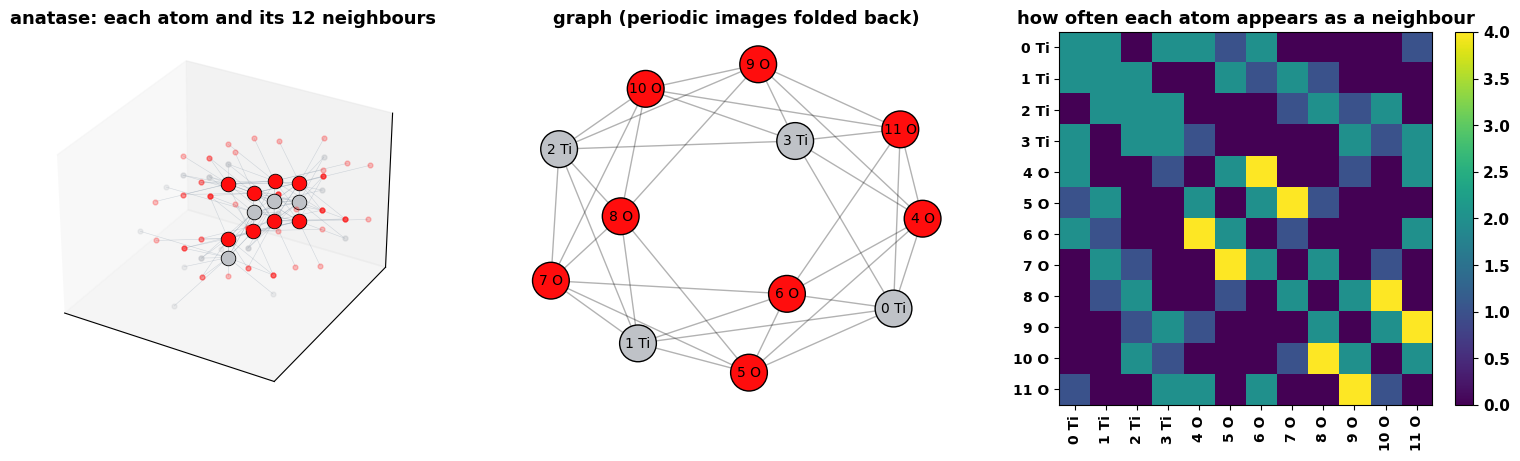

times an atom is its own neighbour, through a periodic image: 8


In [7]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3D projection)

ELEM_COLOUR = {"Ti": "#BFC2C7", "O": "#FF0D0D", "Si": "#F0C8A0", "Zn": "#7D80B0",
               "S": "#FFFF30", "C": "#404040"}


def colour_of(specie):
    """Colour of an element; anything not in the table stays grey."""
    return ELEM_COLOUR.get(str(specie), "#888888")


def panel_real_space(ax, struct, nbrs, name, max_num_nbr):
    """Left panel - in real space, a line from each atom to each of its neighbours."""
    for site, row in zip(struct, nbrs):
        for nb in row:
            p, q = site.coords, nb.coords
            ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]],
                    lw=0.4, color="#8899AA", alpha=0.35)
            ax.scatter(*nb.coords, s=12, alpha=0.25, depthshade=False,
                       color=colour_of(nb.specie))
    for site in struct:
        ax.scatter(*site.coords, s=110, edgecolor="black", linewidth=0.6, depthshade=False,
                   color=colour_of(site.specie))
    ax.set_title(f"{name}: each atom and its {max_num_nbr} neighbours", fontsize=13)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])


def panel_graph(ax, struct, idx):
    """Middle panel - the abstract graph, periodic images folded back onto their atom."""
    G = nx.Graph()
    for i, site in enumerate(struct):
        G.add_node(i, el=str(site.specie))
    for i, row in enumerate(idx):
        for j in row:
            if int(j) != i:
                G.add_edge(i, int(j))
    pos = nx.spring_layout(G, seed=0)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=700, edgecolors="black",
                           node_color=[colour_of(G.nodes[k]["el"]) for k in G])
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10,
                            labels={k: f"{k} {G.nodes[k]['el']}" for k in G})
    ax.set_title("graph (periodic images folded back)", fontsize=13)
    ax.axis("off")


def panel_adjacency(fig, ax, idx, tick):
    """Right panel - how often each atom appears as a neighbour; returns that matrix."""
    n = len(tick)
    C = np.zeros((n, n))
    for i, row in enumerate(idx):
        for j in row:
            C[i, int(j)] += 1
    im = ax.imshow(C, cmap="viridis")
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks(range(n)); ax.set_xticklabels(tick, rotation=90, fontsize=10)
    ax.set_yticks(range(n)); ax.set_yticklabels(tick, fontsize=10)
    ax.set_title("how often each atom appears as a neighbour", fontsize=13)
    return C


def draw_crystal_graph(struct, name="", max_num_nbr=MAX_NBR, radius=RADIUS):
    """Draw the crystal graph in three panels: real space, abstract graph, adjacency counts."""
    nbrs = [sorted(nb, key=lambda x: x[1])[:max_num_nbr]
            for nb in struct.get_all_neighbors(radius, include_index=True)]
    idx = np.array([[nb.index for nb in row] for row in nbrs])
    tick = [f"{i} {struct[i].specie}" for i in range(len(struct))]

    fig = plt.figure(figsize=(15.5, 4.6))
    panel_real_space(fig.add_subplot(1, 3, 1, projection="3d"), struct, nbrs,
                     name, max_num_nbr)
    panel_graph(fig.add_subplot(1, 3, 2), struct, idx)
    C = panel_adjacency(fig, fig.add_subplot(1, 3, 3), idx, tick)
    fig.tight_layout()
    return fig, C


_, C_anatase = draw_crystal_graph(anatase, "anatase")
plt.show()
print("times an atom is its own neighbour, through a periodic image:",
      int(np.trace(C_anatase)))

A count of 2 or more in the adjacency panel means the same atom entered the neighbour list
through several periodic images.

That is the skeleton of the graph. It does not yet carry which element an atom is, or how
long a bond is.

**This skeleton is not the only skeleton.** `the 12 nearest within 8 Å, padded if short` is
the rule CGCNN chose, and a different rule turns the same crystal into a different graph.
Another repository doing the same job (`GNN-materials`, MIT License) chooses
differently in every row.

| | CGCNN (used here) | GNN-materials |
|---|---|---|
| cutoff | 8 Å | 5.5 Å |
| neighbours | fixed at the 12 nearest | every one inside the cutoff — a different count per atom |
| when short | padded at `radius + 1` | no padding; the count was never fixed |
| direction | the 12 nearest of each atom, so i→j can survive without j→i | i→j and j→i are always both recorded |
| periodicity | `get_all_neighbors` finds the periodic images | an n×n×n supercell is actually built and measured |

A fixed 12 gives every atom the same array shape, which is easy to handle, and in return the
neighbour list is cut far closer than the stated cutoff wherever the packing is dense — Part
8 shows anatase reaching 3.06–3.78 Å rather than 8 Å. Counting everything inside the cutoff
removes that truncation and gives up the fixed shape. Neither is wrong, and **where you draw
the graph is already a choice of features.**

## Part 3: Attaching element features to the nodes

Every node gets a 92-dimensional vector. `atom_init.json` from the CGCNN repository maps an
atomic number to 92 zeros and ones. According to the paper (Table S1) it is a one-hot
binning of nine elemental properties, and it is a fixed table that is not trained.

In [8]:
raw = json.loads(ATOM_INIT.read_text())
M = np.array([raw[str(z)] for z in sorted(map(int, raw))])

print(f"{len(raw)} elements listed, whole table {M.shape}, set of values "
      f"{sorted(set(M.ravel().tolist()))}")
print(f"ones per element {M.sum(axis=1).min()} to {M.sum(axis=1).max()}, "
      f"columns that are never one: {int((M.sum(axis=0) == 0).sum())}")
print()
for el, z in [("Ti", 22), ("O", 8)]:
    print(f"{el} (Z={z}) positions that are one: "
          f"{np.flatnonzero(np.array(raw[str(z)])).tolist()}")
print("positions where Ti and O are both one:",
      int((np.array(raw['22']) * np.array(raw['8'])).sum()))

100 elements listed, whole table (100, 92), set of values [0, 1]
ones per element 6 to 9, columns that are never one: 2

Ti (Z=22) positions that are one: [4, 22, 28, 40, 49, 61, 72, 80, 85]
O (Z=8) positions that are one: [16, 20, 34, 37, 51, 64, 74, 79, 86]
positions where Ti and O are both one: 0


node feature matrix (12, 92)  (12 atoms x 92)


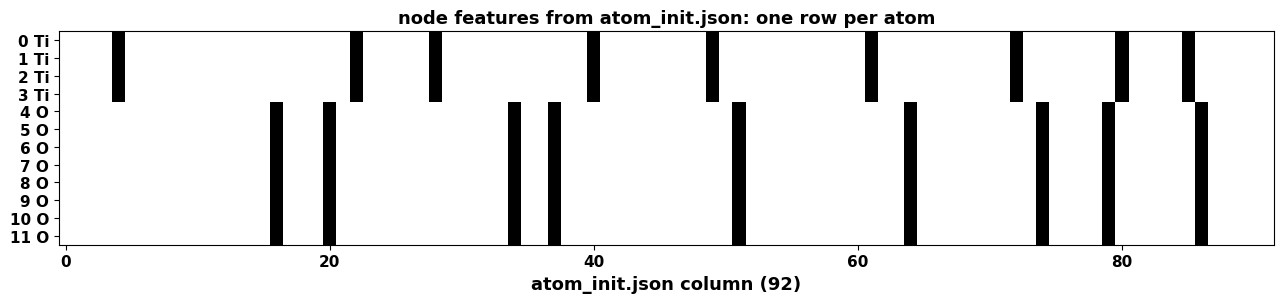

In [9]:
def node_features(struct, table):
    """Attach the 92-dimensional element feature to each atom. Decided by the element alone."""
    return np.vstack([table[str(site.specie.Z)] for site in struct]).astype(float)


atom_fea = node_features(anatase, raw)
print(f"node feature matrix {atom_fea.shape}  ({len(anatase)} atoms x 92)")

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.imshow(atom_fea, cmap="Greys", aspect="auto", interpolation="nearest")
atom_rows(ax)
ax.set_xlabel("atom_init.json column (92)")
ax.set_title("node features from atom_init.json: one row per atom", fontsize=13)
plt.tight_layout()
plt.show()

The four Ti rows are identical and the eight O rows are identical. `atom_init.json` is a
table looked up by atomic number, so the same element gets the same row in whichever crystal
it sits. So far only composition information has entered the nodes.

### Three ways to write an element down as numbers

The width of 92 is also a choice. The same thing can be written far shorter, and the two
reference repositories give two different answers.

| written as | Ti | O | dim | source |
|---|---|---|---|---|
| one atomic number | `22` | `8` | 1 | `Crystal_graphs` in `CGCNN_tutorial` |
| element properties, value as is | `[22, 1.54, 47.87, 1.40]` | `[8, 3.44, 16.00, 0.60]` | 4 | `atoms_dict.json` in `GNN-materials` |
| one-hot bins | 9 of 92 columns on | 9 of 92 columns on | 92 | `atom_init.json` (used here) |

On the bottom row Ti and O light the same **number** of columns. What differs is which
ones, and as the cell above printed, not one of them is on for both.

The middle row is atomic number, electronegativity, atomic mass and radius. The 92 columns
above come from the same kind of property — electronegativity is in both, written as `1.54`
on one row and as a 1 in whichever bin 1.54 falls into on the other.

Writing the value as is says that O at 3.44 is 2.2 times Ti at 1.54, and a linear model
multiplies that ratio straight into a coefficient. The one-hot bins make no such claim, at
the cost of several columns per property - ten for electronegativity - and of telling two
elements in the same bin apart on that property. Raw values also arrive on different scales — a mass of 47.87 beside a radius
of 0.60 — so normalisation follows them, which a table of zeros and ones never needs.

Which is better cannot be settled here. All three are in the Part 7 catalogue, so swap them
into the `node` slot of `RECIPE`.

(GNN-materials carries these four in a table of its own; here the same four are read from
pymatgen. Two values differ: the first is a 0-based element index (21) there and the
atomic number (22) here, and the radius is an ionic radius of 176 pm there against an atomic
radius of 1.40 Å here.)

### Adding node features from matminer

A matminer site featurizer returns a vector per atom, so it can be concatenated straight
onto the node features. Here is everything in `matminer.featurizers.site`, checked one by
one.

| featurizer | dim | what it looks at | needs |
|---|---|---|---|
| `SiteElementalProperty` (seko-prb-2017) | 22 | properties of the element on that site | — |
| `CoordinationNumber` | 1 | coordination number (`VoronoiNN` by default) | — |
| `CrystalNNFingerprint` (ops) | 61 | coordination-polyhedron order parameters | — |
| `OPSiteFingerprint` | 37 | the same thing by a different route | — |
| `ChemEnvSiteFingerprint` (simple) | 61 | ChemEnv coordination environments | — |
| `VoronoiFingerprint` | 30 | Voronoi polyhedron indicators | — |
| `IntersticeDistribution` | 12 | distribution of the gaps between atoms | — |
| `BondOrientationalParameter` | 10 | Steinhardt bond-orientational order parameters | — |
| `GaussianSymmFunc` | 8 | Behler–Parrinello symmetry functions | — |
| `AGNIFingerprints` | 32 | AGNI descriptor (includes directional components) | — |
| `AverageBondLength` | 1 | mean bond length | a neighbour-finder argument |
| `AverageBondAngle` | 1 | mean bond angle | a neighbour-finder argument |
| `LocalPropertyDifference` (ward-prb-2017) | 22 | property difference against the neighbours | — |
| `GeneralizedRadialDistributionFunction` (gaussian) | 10 | a per-site RDF | — |
| `AngularFourierSeries` (gaussian) | 400 | angular Fourier series | about 1.9 s per site |
| `EwaldSiteEnergy` | 1 | per-site Ewald energy | oxidation states |
| `ChemicalSRO` | 2 | deviation of the neighbour composition | `fit` |
| `SOAP` | — | series expansion of the atomic environment | `dscribe` installed |

Let us attach the nine that run with no preparation.

In [10]:
from matminer.featurizers.site import (AGNIFingerprints, AverageBondAngle, AverageBondLength,
                                       CoordinationNumber, CrystalNNFingerprint, GaussianSymmFunc,
                                       LocalPropertyDifference, SiteElementalProperty,
                                       VoronoiFingerprint)

NODE_EXTRA = {
    "SiteElementalProperty": SiteElementalProperty.from_preset("seko-prb-2017"),
    "CoordinationNumber": CoordinationNumber(),
    "CrystalNNFingerprint": CrystalNNFingerprint.from_preset("ops"),
    "VoronoiFingerprint": VoronoiFingerprint(),
    "GaussianSymmFunc": GaussianSymmFunc(),
    "AGNIFingerprints": AGNIFingerprints(),
    "AverageBondLength": AverageBondLength(CrystalNN()),
    "AverageBondAngle": AverageBondAngle(CrystalNN()),
    "LocalPropertyDifference": LocalPropertyDifference.from_preset("ward-prb-2017"),
}

ti = [i for i in range(len(anatase)) if str(anatase[i].specie) == "Ti"]
ox = [i for i in range(len(anatase)) if str(anatase[i].specie) == "O"]


def site_matrix(fz, struct):
    """Run a site featurizer on every atom and stack the result as (atoms, columns)."""
    return np.array([fz.featurize(struct, i) for i in range(len(struct))], dtype=float)


blocks, rows = {}, []
for name, fz in NODE_EXTRA.items():
    t0 = time.time()
    X = site_matrix(fz, anatase)
    blocks[name] = X
    rows.append({"featurizer": name, "dim": X.shape[1],
                 "time (ms)": round((time.time() - t0) * 1000),
                 "Ti rows equal": bool(np.allclose(X[ti], X[ti][0], atol=1e-6)),
                 "O rows equal": bool(np.allclose(X[ox], X[ox][0], atol=1e-6))})
display(pd.DataFrame(rows).set_index("featurizer"))

X_extra = np.hstack([blocks[k] for k in NODE_EXTRA])
node_full = np.hstack([atom_fea, X_extra])
print(f"atom_init 92 + matminer {X_extra.shape[1]} = {node_full.shape[1]} node features")

,dim,time (ms),Ti rows equal,O rows equal
featurizer,,,,
SiteElementalProperty,22,0,True,True
CoordinationNumber,1,873,True,True
CrystalNNFingerprint,61,54,True,True
VoronoiFingerprint,30,33,True,True
GaussianSymmFunc,8,29,True,True
AGNIFingerprints,32,9,True,False
AverageBondLength,1,39,True,True
AverageBondAngle,1,39,True,True
LocalPropertyDifference,22,103,True,True


atom_init 92 + matminer 178 = 270 node features


The Ti rows agree with one another and so do the O rows, for the reason seen in Part 2: in
anatase the four Ti are equivalent and the eight O are equivalent.

Only `AGNIFingerprints` gives different values across the O rows. That descriptor keeps the
x, y and z components of the neighbour directions, so two sites that are symmetrically the
same but oriented differently get different values.

The coordination numbers show how much the answer depends on the neighbour definition.

In [11]:
cn = blocks["CoordinationNumber"].ravel()
cnnf = NODE_EXTRA["CrystalNNFingerprint"]
lab = cnnf.feature_labels()
Xc = blocks["CrystalNNFingerprint"]

print("CoordinationNumber (VoronoiNN):", cn)
print("AverageBondLength (CrystalNN):", np.round(blocks["AverageBondLength"].ravel(), 4))
print()
for i in [ti[0], ox[0]]:
    top = np.argsort(-Xc[i])[:4]
    print(f"site {i} ({anatase[i].specie}) largest CrystalNN order parameters:")
    for j in top:
        print(f"    {lab[j]:34s} {Xc[i, j]:.3f}")

CoordinationNumber (VoronoiNN): [ 6.  6.  6.  6. 17. 17. 17. 17. 17. 17. 17. 17.]
AverageBondLength (CrystalNN): [1.9543 1.9543 1.9543 1.9543 1.9543 1.9543 1.9543 1.9543 1.9543 1.9543 1.9543 1.9543]

site 0 (Ti) largest CrystalNN order parameters:
    wt CN_6                            0.965
    octahedral CN_6                    0.556
    pentagonal pyramidal CN_6          0.477
    hexagonal planar CN_6              0.212
site 4 (O) largest CrystalNN order parameters:
    wt CN_3                            0.965
    T-shaped CN_3                      0.551
    trigonal non-coplanar CN_3         0.369
    trigonal planar CN_3               0.219


`VoronoiNN` counts the coordination number of O as 17, because it counts every neighbour
that shares a Voronoi face. `CrystalNNFingerprint` gives the same site `wt CN_3` of 0.965
and reads it as three-coordinated. For Ti both routes say 6. The coordination number depends
on which neighbour definition is used.

`AverageBondLength` is 1.9543 Å on every site, because a Ti–O bond is the same bond whether
it is seen from the Ti or from the O.

Let us draw the extended node feature matrix. The 92 columns on the left of the line are
`atom_init.json`; the right side is what matminer added.

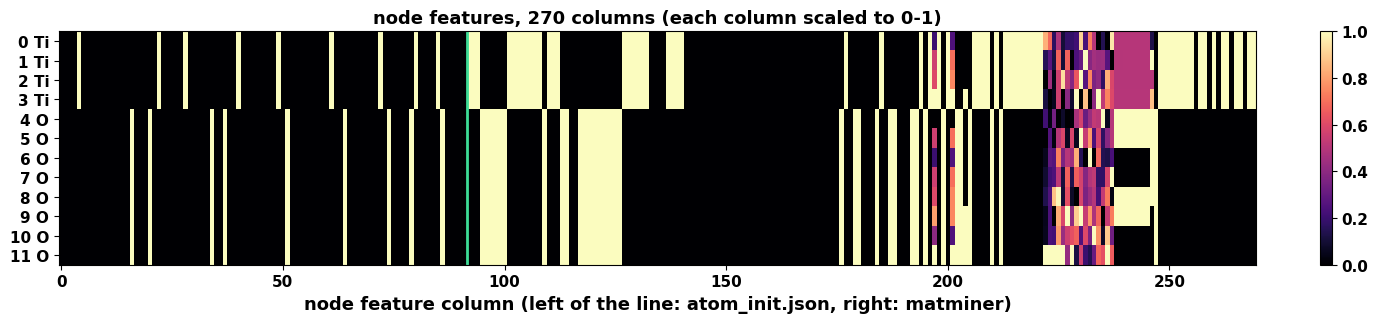

In [12]:
def scale01(M):
    """Stretch each column to 0-1. A column that never varies stays 0 (nothing to divide by)."""
    lo, hi = M.min(axis=0), M.max(axis=0)
    out = np.zeros_like(M, dtype=float)
    wide = hi > lo
    out[:, wide] = (M[:, wide] - lo[wide]) / (hi - lo)[wide]
    return out


fig, ax = plt.subplots(figsize=(14, 3.4))
im = ax.imshow(scale01(node_full), aspect="auto", cmap="magma", interpolation="nearest")
ax.axvline(92 - 0.5, color="#3DDC97", lw=2)
atom_rows(ax)
ax.set_xlabel("node feature column (left of the line: atom_init.json, right: matminer)")
ax.set_title(f"node features, {node_full.shape[1]} columns "
             "(each column scaled to 0-1)", fontsize=13)
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.show()

The `atom_init.json` side is only zeros and ones; the matminer side is continuous. In both
parts the Ti rows and the O rows have different patterns. The difference is that the left
side is decided by the element alone, and the right side by the arrangement of the
neighbours around that site.

## Part 4: Attaching bond features to the edges

Every edge carries two things: the distance to the neighbour, and which element that
neighbour is. The distances were already computed in Part 2.

In [13]:
nbr_species = np.array([[str(anatase[j].specie) for j in row] for row in nbr_idx])

print("edge distances (atoms x 12 neighbours)")
display(pd.DataFrame(np.round(nbr_dist, 3), index=LABEL,
                     columns=[f"nbr {k}" for k in range(MAX_NBR)]))
print("the element each edge points at")
display(pd.DataFrame(nbr_species, index=LABEL,
                     columns=[f"nbr {k}" for k in range(MAX_NBR)]))

edge distances (atoms x 12 neighbours)


,nbr 0,nbr 1,nbr 2,nbr 3,nbr 4,nbr 5,nbr 6,nbr 7,nbr 8,nbr 9,nbr 10,nbr 11
0 Ti,1.936,1.936,1.936,1.936,1.992,1.992,3.059,3.059,3.059,3.059,3.783,3.783
1 Ti,1.936,1.936,1.936,1.936,1.992,1.992,3.059,3.059,3.059,3.059,3.783,3.783
2 Ti,1.936,1.936,1.936,1.936,1.992,1.992,3.059,3.059,3.059,3.059,3.783,3.783
3 Ti,1.936,1.936,1.936,1.936,1.992,1.992,3.059,3.059,3.059,3.059,3.783,3.783
4 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,3.059,3.059,3.059
5 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,3.059,3.059,3.059
6 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,3.059,3.059,3.059
7 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,3.059,3.059,3.059
8 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,3.059,3.059,3.059
9 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,3.059,3.059,3.059


the element each edge points at


,nbr 0,nbr 1,nbr 2,nbr 3,nbr 4,nbr 5,nbr 6,nbr 7,nbr 8,nbr 9,nbr 10,nbr 11
0 Ti,O,O,O,O,O,O,Ti,Ti,Ti,Ti,Ti,Ti
1 Ti,O,O,O,O,O,O,Ti,Ti,Ti,Ti,Ti,Ti
2 Ti,O,O,O,O,O,O,Ti,Ti,Ti,Ti,Ti,Ti
3 Ti,O,O,O,O,O,O,Ti,Ti,Ti,Ti,Ti,Ti
4 O,Ti,Ti,Ti,O,O,O,O,O,O,O,O,O
5 O,Ti,Ti,Ti,O,O,O,O,O,O,O,O,O
6 O,Ti,Ti,Ti,O,O,O,O,O,O,O,O,O
7 O,Ti,Ti,Ti,O,O,O,O,O,O,O,O,O
8 O,Ti,Ti,Ti,O,O,O,O,O,O,O,O,O
9 O,Ti,Ti,Ti,O,O,O,O,O,O,O,O,O


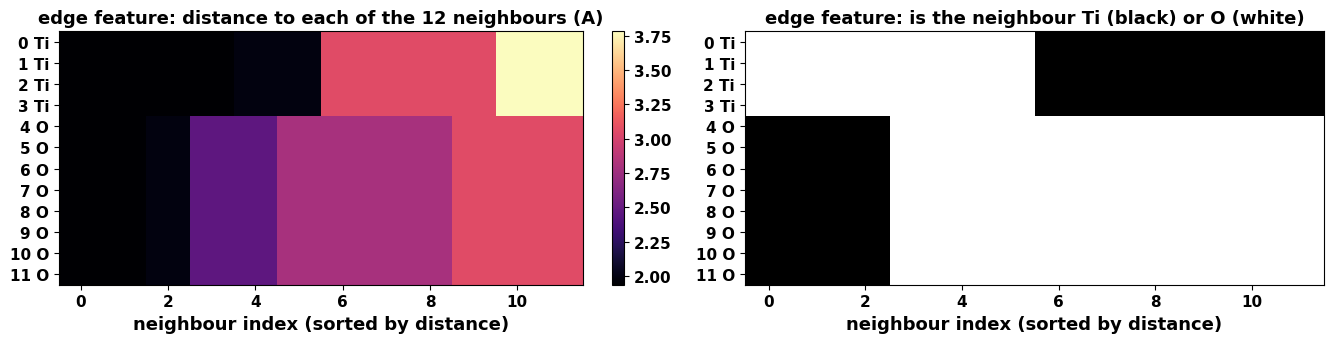

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.6))
im = axes[0].imshow(nbr_dist, aspect="auto", cmap="magma")
axes[0].set_title("edge feature: distance to each of the 12 neighbours (A)", fontsize=13)
plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].imshow((nbr_species == "Ti").astype(float), aspect="auto", cmap="Greys",
               interpolation="nearest")
axes[1].set_title("edge feature: is the neighbour Ti (black) or O (white)", fontsize=13)
for ax in axes:
    atom_rows(ax)
    ax.set_xlabel("neighbour index (sorted by distance)")
plt.tight_layout()
plt.show()

In the distance panel the left side is dark and it brightens towards the right, because the
neighbours are sorted by distance. The Ti rows and the O rows have different patterns.

When there are fewer than twelve neighbours the remaining slots are filled with
`radius + 1` = 9 Å. Let us make that happen by shrinking the cutoff to 3 Å.

In [15]:
idx_s, dist_s, n_pad_s = neighbour_list(anatase, radius=3.0)
print(f"cutoff 3.0 A: {n_pad_s} of {len(anatase)} atoms padded")
display(pd.DataFrame(np.round(dist_s, 3), index=LABEL,
                     columns=[f"nbr {k}" for k in range(MAX_NBR)]))

cutoff 3.0 A: 12 of 12 atoms padded


,nbr 0,nbr 1,nbr 2,nbr 3,nbr 4,nbr 5,nbr 6,nbr 7,nbr 8,nbr 9,nbr 10,nbr 11
0 Ti,1.936,1.936,1.936,1.936,1.992,1.992,4.000,4.000,4.000,4.0,4.0,4.0
1 Ti,1.936,1.936,1.936,1.936,1.992,1.992,4.000,4.000,4.000,4.0,4.0,4.0
2 Ti,1.936,1.936,1.936,1.936,1.992,1.992,4.000,4.000,4.000,4.0,4.0,4.0
3 Ti,1.936,1.936,1.936,1.936,1.992,1.992,4.000,4.000,4.000,4.0,4.0,4.0
4 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,4.0,4.0,4.0
5 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,4.0,4.0,4.0
6 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,4.0,4.0,4.0
7 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,4.0,4.0,4.0
8 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,4.0,4.0,4.0
9 O,1.936,1.936,1.992,2.464,2.464,2.799,2.799,2.799,2.799,4.0,4.0,4.0


The slots that read 9 are the padded ones. Too small a cutoff empties the graph, which is
why 8 Å is the default.

The official implementation takes one more step here. The distance is not used as it is: it
is passed through a set of Gaussians with different centres and spread into a vector. This
is `GaussianDistance` in `cgcnn/data.py`, applied to the edge distances on the last line of
`CIFData.__getitem__`. The edge feature the network receives is that vector, not a single
distance.

41 filter centres: 0.0, 0.2, ... , 8.0 A (spacing 0.2 A, var 0.2)
distance array (12, 12) -> edge features (12, 12, 41),  144 numbers -> 5904


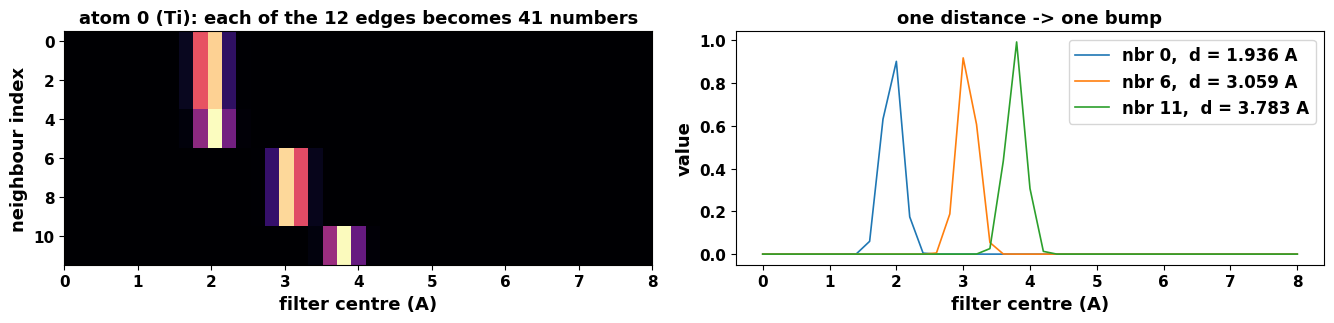

In [16]:
# Source: GaussianDistance in cgcnn/data.py (T. Xie, MIT License)
DMIN, DMAX, STEP = 0.0, RADIUS, 0.2


def expand_distance(dist, dmin=DMIN, dmax=DMAX, step=STEP, var=None):
    """Spread a distance over a set of Gaussians with different centres.

    The centres run from dmin to dmax with spacing step; var defaults to step.
    """
    centres = np.arange(dmin, dmax + step, step)
    var = step if var is None else var
    return np.exp(-(dist[..., np.newaxis] - centres) ** 2 / var ** 2)


centres = np.arange(DMIN, DMAX + STEP, STEP)
nbr_fea = expand_distance(nbr_dist)

print(f"{len(centres)} filter centres: {centres[0]:.1f}, {centres[1]:.1f}, ... , "
      f"{centres[-1]:.1f} A (spacing {STEP} A, var {STEP})")
print(f"distance array {nbr_dist.shape} -> edge features {nbr_fea.shape},  "
      f"{nbr_dist.size} numbers -> {nbr_fea.size}")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.4))
axes[0].imshow(nbr_fea[0], aspect="auto", cmap="magma", interpolation="nearest",
               extent=[DMIN, DMAX, MAX_NBR - 0.5, -0.5])
axes[0].set_xlabel("filter centre (A)")
axes[0].set_ylabel("neighbour index")
axes[0].set_title(f"atom 0 ({anatase[0].specie}): each of the 12 edges "
                  f"becomes {len(centres)} numbers", fontsize=13)

for k in (0, 6, 11):
    axes[1].plot(centres, nbr_fea[0, k], lw=1.2,
                 label=f"nbr {k},  d = {nbr_dist[0, k]:.3f} A")
axes[1].set_xlabel("filter centre (A)")
axes[1].set_ylabel("value")
axes[1].set_title("one distance -> one bump", fontsize=13)
axes[1].legend(fontsize=12)
plt.tight_layout()
plt.show()

One distance has become 41 numbers. The neighbours are sorted by distance, so the bright
band steps down to the right in the left panel. In the right panel each bump stands at its
own distance. The centres are 0.2 Å apart, so a distance that falls between two centres has
a peak below 1: 0.90 at 1.936 Å.

`main.py` reads the last dimension of this array, 41, and uses it as the edge input width of
the model.

**Can matminer add edge features?** matminer has no featurizer that returns a value for one
edge. Everything it offers about bonds is a statistic over the whole crystal:
`BondFractions` gives the bond fraction per element pair, `BagofBonds` a collection of 1/r
over the bonds, and `PartialRadialDistributionFunction` a distance histogram per element
pair — and all three want `fit` called first and then return one vector per structure. What
goes on an edge, like the distance and the neighbouring element, has to be computed
directly.

## Part 5: Attaching global features

Node and edge features belong to one atom and one bond. Some values come one per crystal
instead: the lattice, the volume, the density, the space group — things one cannot ask a
single atom about.

The CGCNN network takes only nodes, edges and neighbour indices as its input
(`cgcnn/model.py`), and the representation of one crystal is the mean over its node
features. The original implementation has no slot for global features; from here on we are
widening the representation. We start with the ones we can write down ourselves.

In [17]:
def global_features(struct):
    """Values that come one per crystal. Their count does not depend on the atom count."""
    a, b, c = struct.lattice.abc
    al, be, ga = struct.lattice.angles
    sg = SpacegroupAnalyzer(struct, symprec=0.1)
    frac = struct.composition.fractional_composition
    return pd.Series({
        "a (A)": round(a, 4), "b (A)": round(b, 4), "c (A)": round(c, 4),
        "alpha": round(al, 2), "beta": round(be, 2), "gamma": round(ga, 2),
        "volume (A^3)": round(struct.volume, 3),
        "volume per atom": round(struct.volume / len(struct), 4),
        "density (g/cm^3)": round(float(struct.density), 4),
        "n atoms": len(struct),
        "spacegroup number": sg.get_space_group_number(),
        "frac Ti": round(frac.get_atomic_fraction("Ti"), 4),
        "frac O": round(frac.get_atomic_fraction("O"), 4),
    })


g_hand = global_features(anatase)
print(f"{len(g_hand)} hand-written global features")
display(g_hand.to_frame("anatase"))

13 hand-written global features


,anatase
a (A),3.7825
b (A),3.7825
c (A),9.6150
alpha,90.0000
beta,90.0000
gamma,90.0000
volume (A^3),137.5680
volume per atom,11.4640
density (g/cm^3),3.8561
n atoms,12.0000


A matminer structure featurizer returns one vector per structure, so it fits the global slot
directly. The list of structure features in the pre-class notebook is the list of candidates.
Let us attach the seven that run quickly.

| featurizer | dim | what it looks at |
|---|---|---|
| `DensityFeatures` | 3 | density, volume per atom, packing fraction |
| `MaximumPackingEfficiency` | 1 | maximum packing fraction |
| `GlobalSymmetryFeatures` | 3 | space-group number, crystal system, number of symmetry operations |
| `StructuralComplexity` | 2 | Shannon entropy of the structure |
| `ChemicalOrdering` | 3 | Warren-Cowley ordering parameters |
| `StructuralHeterogeneity` | 9 | spread of the Voronoi volumes and distances |
| `Dimensionality` | 1 | connectivity dimension |

Bigger ones are available too: `XRDPowderPattern` with 128 dimensions,
`RadialDistributionFunction` with 200, `OrbitalFieldMatrix` with 1024 and `JarvisCFID` with
1557. Here we keep to the small ones so that the values can be read on screen.

In [18]:
from matminer.featurizers.structure import (ChemicalOrdering, DensityFeatures, Dimensionality,
                                            GlobalSymmetryFeatures, MaximumPackingEfficiency,
                                            StructuralComplexity, StructuralHeterogeneity)

GLOBAL_EXTRA = {
    "DensityFeatures": DensityFeatures(),
    "MaximumPackingEfficiency": MaximumPackingEfficiency(),
    # crystal_system is a string and is_centrosymmetric is a bool, so take the numeric ones.
    "GlobalSymmetryFeatures": GlobalSymmetryFeatures(
        desired_features=["spacegroup_num", "crystal_system_int", "n_symmetry_ops"]),
    "StructuralComplexity": StructuralComplexity(),
    "ChemicalOrdering": ChemicalOrdering(),
    "StructuralHeterogeneity": StructuralHeterogeneity(),
    "Dimensionality": Dimensionality(),
}

parts, rows = [], []
for name, fz in GLOBAL_EXTRA.items():
    t0 = time.time()
    v = np.array(fz.featurize(anatase), dtype=float)
    parts.append(pd.Series(v, index=fz.feature_labels()))
    rows.append({"featurizer": name, "dim": len(v),
                 "time (ms)": round((time.time() - t0) * 1000)})
display(pd.DataFrame(rows).set_index("featurizer"))

g_matminer = pd.concat(parts)
print(f"{len(g_matminer)} global features added by matminer")
display(g_matminer.round(4).to_frame("anatase"))

g_full = pd.concat([g_hand, g_matminer])
print(f"hand-written {len(g_hand)} + matminer {len(g_matminer)} = {len(g_full)} global features")

,dim,time (ms)
featurizer,,
DensityFeatures,3,1
MaximumPackingEfficiency,1,606
GlobalSymmetryFeatures,3,3
StructuralComplexity,2,1
ChemicalOrdering,3,59
StructuralHeterogeneity,9,1
Dimensionality,1,45


22 global features added by matminer


,anatase
density,3.8561
vpa,11.4640
packing fraction,0.3868
max packing efficiency,0.3312
spacegroup_num,141.0000
crystal_system_int,4.0000
n_symmetry_ops,32.0000
structural complexity per atom,0.9183
structural complexity per cell,11.0196
mean ordering parameter shell 1,0.3134


hand-written 13 + matminer 22 = 35 global features


The density and the volume per atom from `DensityFeatures` are the same numbers we wrote by
hand. They are in there twice, so in practice the overlapping columns have to be filtered
out.

## Part 6: The finished representation

The three layers together are the representation of the one anatase CIF.

In [19]:
summary = pd.DataFrame([
    {"layer": "node (atom)", "shape": str(node_full.shape),
     "made of": "atom_init.json 92 + matminer site features 178",
     "what it holds": "which element sits there and how its neighbours are arranged"},
    {"layer": "edge (bond) distance", "shape": str(nbr_fea.shape),
     "made of": f"distance out to the 12th neighbour, spread over {nbr_fea.shape[-1]} Gaussians",
     "what it holds": "how far apart the atoms are"},
    {"layer": "edge (bond) neighbour", "shape": str(nbr_idx.shape),
     "made of": "index of the neighbouring atom (its element can be followed up)",
     "what it holds": "who is connected to whom"},
    {"layer": "global (crystal)", "shape": f"({len(g_full)},)",
     "made of": f"hand-written {len(g_hand)} + matminer structure features {len(g_matminer)}",
     "what it holds": "lattice, density, symmetry"},
])
display(summary.set_index("layer"))

print(f"one anatase CIF has become "
      f"{node_full.size + nbr_fea.size + nbr_idx.size + len(g_full)} numbers.")

,shape,made of,what it holds
layer,,,
node (atom),"(12, 270)",atom_init.json 92 + matminer site features 178,which element sits there and how its neighbour...
edge (bond) distance,"(12, 12, 41)","distance out to the 12th neighbour, spread ove...",how far apart the atoms are
edge (bond) neighbour,"(12, 12)",index of the neighbouring atom (its element ca...,who is connected to whom
global (crystal),"(35,)",hand-written 13 + matminer structure features 22,"lattice, density, symmetry"


one anatase CIF has become 9323 numbers.


The first dimension of the nodes and the edges is the atom count, 12. Put in a crystal with
a different atom count and it changes. Nothing is zero-padded to a common length the way
`SineCoulombMatrix` does; the sizes simply differ. Only the global features have a count that
does not depend on the crystal.

With `atom_init.json` alone the nodes carry only element information and all of the structure
sits on the edges. Adding matminer site featurizers makes the nodes carry the arrangement
around each site as well. The CGCNN network takes nodes and edges as its input and learns the
mixing of neighbour information itself, which is why the original implementation puts only
element information on the nodes.

## Part 7: Try it yourself — designing a feature set for the band gap

Parts 2 to 6 turned one CIF into a representation. A representation is built in order to
predict something, so the next question is which part of it to carry when the target is a
property. Notebook 01 Part 6 asked a question of this shape with a correlation matrix; here
the target is one property, the band gap, and the columns are the four layers built in this
notebook.

A correlation needs more than one crystal, so anatase alone will not do. The 100 Materials
Project entries in `data/mp100_*` come back in — the same set as Part 6 of notebook 01 and
Part 7 of notebook 02 — and their index carries `band_gap`.

Features are chosen by name. There is a catalogue below, and writing the names you want into
the four slots — `node`, `edge`, `site`, `global` — of `RECIPE` builds that combination. The
feature vector of a single crystal is printed, column names and all, before the 100 entries.

Node, edge and site features come one per atom or one per bond, so each crystal has to be
reduced to a single vector first. The mean over the atoms is what CGCNN itself uses: the
crystal vector in `cgcnn/model.py` is the mean of the node features. Before the 100 entries,
what that mean does to the three TiO₂ polymorphs.

In [20]:
POLY = ["TiO2_rutile.cif", "TiO2_anatase.cif", "TiO2_brookite.cif"]

pooled = {}
for f in POLY:
    s = Structure.from_file(CIF_DIR / f)
    a = node_features(s, raw)                                    # atom_init, 92 per atom
    c = site_matrix(cnnf, s)                                     # CrystalNN ops, 61 per atom
    pooled[f.removeprefix("TiO2_").removesuffix(".cif")] = (a.mean(axis=0),
                                                            np.hstack([a, c]).mean(axis=0))

print("mean over the atoms - largest difference between two TiO2 polymorphs")
for i, p in enumerate(pooled):
    for q in list(pooled)[i + 1:]:
        print(f"  {p:8s} vs {q:8s}   atom_init only {np.abs(pooled[p][0] - pooled[q][0]).max():.4f}"
              f"   with CrystalNNFingerprint {np.abs(pooled[p][1] - pooled[q][1]).max():.4f}")

mean over the atoms - largest difference between two TiO2 polymorphs
  rutile   vs anatase    atom_init only 0.0000   with CrystalNNFingerprint 0.2405
  rutile   vs brookite   atom_init only 0.0000   with CrystalNNFingerprint 0.1401
  anatase  vs brookite   atom_init only 0.0000   with CrystalNNFingerprint 0.1004


0.0000 — the three polymorphs give exactly the same vector. A mean over a table that is
looked up by element is a composition-weighted average of that table, so any two crystals
with the same fractional composition land on the same point. All three files are exactly
1:2, which is why the difference is 0 and not a rounding error. It is the result of Part 4
of notebook 02 arrived at from the other side: with `atom_init.json` on the nodes and the
mean as the pooling, the crystal vector is a composition feature.

Attaching `CrystalNNFingerprint` to each atom pulls them apart again, by 0.10 to 0.24,
because a site feature is decided by the arrangement around the atom. CGCNN takes the other
route: the convolution layers mix the neighbour information into the nodes through the edges
first, and the mean is taken afterwards. We are pooling with no convolution, so the node
block below carries composition and nothing else — worth remembering when the correlations
are read.

In [21]:
from monty.serialization import loadfn

mp100 = pd.read_csv(DATA_DIR / "mp100_index.csv")
S100 = loadfn(str(DATA_DIR / "mp100_structures.json.gz"))

# atom_init.json is nine elemental properties laid side by side, each of them one-hot
# (Table S1 of the paper). A property ends at the column where a row would pick up a second
# one, so the boundaries can be read off the table itself.
PROPS = ["group", "period", "electronegativity", "covalent radius", "valence electrons",
         "ionization energy", "electron affinity", "block", "atomic volume"]
table = np.array([raw[str(z)] for z in sorted(map(int, raw))])
widths, start = [], 0
for j in range(1, table.shape[1] + 1):
    if j == table.shape[1] or table[:, start:j + 1].sum(axis=1).max() > 1:
        widths.append(j - start)
        start = j
assert len(widths) == len(PROPS), widths


def bin_labels(prop, w):
    """Name the one-hot columns of one property. Continuous ones are binned low to high."""
    if prop == "group":          # the first bin holds the f-block, which has no group number
        return ["group f-block"] + [f"group {k}" for k in range(1, w)]
    if prop == "period":
        return [f"period {k + 1}" for k in range(w)]
    if prop == "block":
        return [f"block {b}" for b in "spdf"]
    if prop == "valence electrons":
        return [f"{k + 1} valence electron" + ("" if k == 0 else "s")
                for k in range(w)]
    return [f"{prop} bin {k + 1}/{w}" for k in range(w)]


node_labels = [lab for p, w in zip(PROPS, widths) for lab in bin_labels(p, w)]
print("atom_init.json:", ", ".join(f"{p} {w}" for p, w in zip(PROPS, widths)))

print(f"\n{len(S100)} crystals, {min(len(s) for s in S100)} ~ {max(len(s) for s in S100)} "
      f"atoms per cell")
print(f"band gap: {int((mp100.band_gap == 0).sum())} of {len(mp100)} are 0 eV, the rest "
      f"reach {mp100.band_gap.max():.2f} eV")

atom_init.json: group 19, period 7, electronegativity 10, covalent radius 10, valence electrons 12, ionization energy 10, electron affinity 10, block 4, atomic volume 10

100 crystals, 1 ~ 40 atoms per cell
band gap: 29 of 100 are 0 eV, the rest reach 8.72 eV


The nine properties inside `atom_init.json` are the reason the node columns now have names.
Where one property ends and the next begins is not written in the file, but it follows from
the table: the columns of one property are one-hot, so a property ends where a row would pick
up a second one. The widths that come out — 19, 7, 10, 10, 12, 10, 10, 4, 10 — are the group
(with one extra bin for the f-block, which has no group number), the seven periods, the four
blocks, and ten bins each for the properties that are continuous.

### A catalogue of features — pick them by name

From here on, features are chosen **by name**. The cell below builds one catalogue. There are
four slots, and each slot lists the names it accepts together with the number of columns each
name adds.

| slot | one value per | how a crystal is reduced to one vector |
|---|---|---|
| `node` | atom | mean over the atoms |
| `edge` | bond | mean over the bonds |
| `site` | atom | mean over the atoms |
| `global` | crystal | taken as it is |

The `site` slot sits on top of the node slot. A matminer site featurizer from Part 3 returns
one value per atom, so it belongs where the nodes are, but it is kept apart from the element
table (`atom_init.json`) so that the two can be read separately. Leave a slot as an empty
list `[]` and that block drops out entirely.

The catalogue runs every name once on anatase to measure its width and its cost. `100
crystals` is that time multiplied by the number of crystals and the mean atom count — a rough
number, but enough to see what a name will cost before adding it.

In [22]:
# ---------------------------------------------------------------------------
# The feature catalogue. One name builds one block of columns.
#     slot -> {name: (what it is, one crystal -> values, column names)}
# node and site give one value per atom and edge one per bond, so each is pooled into a
# single vector per crystal - the same mean CGCNN uses, seen just above.
# ---------------------------------------------------------------------------
GLOBAL_HAND = [c for c in g_hand.index if c not in ("frac Ti", "frac O")]

NOTE = {  # the one-line description printed in the catalogue
    "SiteElementalProperty": "elemental properties of the atom itself (seko-prb-2017)",
    "CoordinationNumber": "coordination number (VoronoiNN)",
    "CrystalNNFingerprint": "order parameters for the coordination shape",
    "VoronoiFingerprint": "face and volume statistics of the Voronoi polyhedron",
    "GaussianSymmFunc": "Behler-Parrinello symmetry functions",
    "AGNIFingerprints": "AGNI fingerprints, direction resolved",
    "AverageBondLength": "mean bond length to the neighbours (CrystalNN)",
    "AverageBondAngle": "mean bond angle between neighbours (CrystalNN)",
    "LocalPropertyDifference": "difference in elemental properties to the neighbours",
    "DensityFeatures": "density, volume per atom, packing fraction",
    "MaximumPackingEfficiency": "how densely the cell could be packed",
    "GlobalSymmetryFeatures": "space group number, crystal system, symmetry operations",
    "StructuralComplexity": "structural complexity, per atom and per cell",
    "ChemicalOrdering": "chemical ordering in the neighbour shells",
    "StructuralHeterogeneity": "spread of the bond lengths and of the cell sizes",
    "Dimensionality": "dimensionality of the structure (1/2/3D)",
}


def site_mean(fz):
    """Pool a site featurizer over the atoms."""
    return (lambda s: site_matrix(fz, s).mean(axis=0),
            lambda: list(fz.feature_labels()))


def structure_fz(fz):
    """A structure featurizer already gives one vector per crystal."""
    return (lambda s: np.array(fz.featurize(s), dtype=float),
            lambda: list(fz.feature_labels()))


def bond_stats(d):
    """Reduce the array of neighbour distances to four numbers."""
    return np.array([d.mean(), d.min(), d.max(), d.std()])


def element_raw(sp):
    """Four element properties, value as is. The same four as atoms_dict.json in
    GNN-materials, read from pymatgen (an ionic radius in pm there, an atomic radius in A
    here)."""
    el = getattr(sp, "element", sp)
    return [el.Z, el.X, float(el.atomic_mass), float(el.atomic_radius)]


CATALOG = {
    "node": {
        "atom_init": ("the CGCNN element table - fixed by the element alone",
                      lambda s: node_features(s, raw).mean(axis=0),
                      lambda: node_labels),
        "atomic_number": ("the atomic number and nothing else (CGCNN_tutorial)",
                          lambda s: np.array([[site.specie.Z] for site in s],
                                             dtype=float).mean(axis=0),
                          lambda: ["atomic number"]),
        "element_raw": ("four element properties, value as is (GNN-materials)",
                        lambda s: np.array([element_raw(site.specie) for site in s],
                                           dtype=float).mean(axis=0),
                        lambda: ["Z", "electronegativity", "atomic mass",
                                 "atomic radius (A)"]),
    },
    "edge": {
        "gaussian_distance": (f"the neighbour distance spread over {len(centres)} Gaussians",
                              lambda s: expand_distance(neighbour_list(s)[1]).mean(axis=(0, 1)),
                              lambda: [f"{c:.1f} A" for c in centres]),
        "bond_distance_stats": (f"the {MAX_NBR} neighbour distances as mean, min, max, std",
                                lambda s: bond_stats(neighbour_list(s)[1]),
                                lambda: ["mean d (A)", "min d (A)", "max d (A)", "std d (A)"]),
    },
    "site": {name: (NOTE[name], *site_mean(fz)) for name, fz in NODE_EXTRA.items()},
    "global": {
        "lattice": ("hand-built globals - lattice, volume, density, symmetry "
                    "(the TiO2-only composition columns are dropped)",
                    lambda s: global_features(s)[GLOBAL_HAND].to_numpy(dtype=float),
                    lambda: GLOBAL_HAND),
        **{name: (NOTE[name], *structure_fz(fz)) for name, fz in GLOBAL_EXTRA.items()},
    },
}


def show_catalog(struct=None, n_crystals=None):
    """Table of the names on offer. Width and time come from one run on anatase."""
    struct = anatase if struct is None else struct
    n_crystals = len(S100) if n_crystals is None else n_crystals
    scale = np.mean([len(s) for s in S100]) / len(struct)
    rows = []
    for slot, items in CATALOG.items():
        for name, (note, value_fn, _) in items.items():
            t0 = time.time()
            try:
                dim = len(np.asarray(value_fn(struct), dtype=float).ravel())
            except Exception as err:                   # also shows whether it runs at all
                dim, note = 0, f"fails on anatase: {type(err).__name__}"
            ms = (time.time() - t0) * 1000
            rows.append({"slot": slot, "name": name, "dim": dim, "anatase (ms)": round(ms),
                         f"{n_crystals} crystals (s)": round(ms * n_crystals * scale / 1000, 1),
                         "what it is": note})
    return pd.DataFrame(rows).set_index(["slot", "name"])


display(show_catalog())

dim  anatase (ms)  100 crystals (s)                                         what it is
slot   name                                                                                                            
node   atom_init                  92             0               0.0  the CGCNN element table - fixed by the element...
       atomic_number               1             0               0.0  the atomic number and nothing else (CGCNN_tuto...
       element_raw                 4             0               0.0  four element properties, value as is (GNN-mate...
edge   gaussian_distance          41            10               0.6    the neighbour distance spread over 41 Gaussians
       bond_distance_stats         4             7               0.4  the 12 neighbour distances as mean, min, max, std
site   SiteElementalProperty      22             0               0.0  elemental properties of the atom itself (seko-...
       CoordinationNumber          1           650              36.2                    coordination number (VoronoiNN)
       CrystalNNFingerprint       61            54               3.0        order parameters for the coordination shape
       VoronoiFingerprint         30            34               1.9  face and volume statistics of the Voronoi poly...
       GaussianSymmFunc            8            29               1.6               Behler-Parrinello symmetry functions
       AGNIFingerprints           32             9               0.5              AGNI fingerprints, direction resolved
       AverageBondLength           1            39               2.2     mean bond length to the neighbours (CrystalNN)
       AverageBondAngle            1            39               2.2     mean bond angle between neighbours (CrystalNN)
       LocalPropertyDifference    22           534              29.7  difference in elemental properties to the neig...
global lattice                    11             2               0.1  hand-built globals - lattice, volume, density,...
       DensityFeatures             3             0               0.0         density, volume per atom, packing fraction
       MaximumPackingEfficiency    1           570              31.7               how densely the cell could be packed
       GlobalSymmetryFeatures      3             2               0.1  space group number, crystal system, symmetry o...
       StructuralComplexity        2             1               0.1       structural complexity, per atom and per cell
       ChemicalOrdering            3            61               3.4          chemical ordering in the neighbour shells
       StructuralHeterogeneity     9             2               0.1   spread of the bond lengths and of the cell sizes
       Dimensionality              1            44               2.5           dimensionality of the structure (1/2/3D)

`dim` is how many columns a name adds and the two columns on the right are what it costs. A
name that takes a few hundred ms on the 12 atoms of anatase takes tens of seconds over the
100 crystals — `CoordinationNumber` and `MaximumPackingEfficiency` are the two; the rest
finish in a few seconds. Add three or four names and the next two cells grow accordingly.

`bond_distance_stats` summarises the twelve neighbour distances as they are, so if a smaller
cutoff in `neighbour_list` starts padding the rows (the 9 Å slots of Part 2), the padding
enters the mean as well — at the default 8 Å with 12 neighbours none of the 100 crystals pads.

Now write the names into `RECIPE`. The cell below turns **one crystal** into one vector with
that recipe and prints it. It is the place to look at what is being built before going to 100
crystals.

In [23]:
# ===========================================================================
#  This is the cell to edit - put the names from the catalogue into the slots.
# ===========================================================================
RECIPE = {
    "node":   ["atom_init"],              # per atom    - the element table
    "edge":   ["gaussian_distance"],      # per bond    - the neighbour distances
    "site":   ["CrystalNNFingerprint"],   # per atom    - a matminer site feature
    "global": ["lattice"],                # per crystal - lattice, density, symmetry
}
# ===========================================================================


def slot_labels(slot, names):
    """Column names of one slot. With more than one name, each column carries its own."""
    out = []
    for n in names:
        labs = list(CATALOG[slot][n][2]())
        out += labs if len(names) == 1 else [f"{n}: {lab}" for lab in labs]
    return out


def featurize_one(struct, recipe=None):
    """Turn one crystal into one feature vector. The index is (slot, name, column)."""
    recipe = RECIPE if recipe is None else recipe
    keys, vals = [], []
    for slot, names in recipe.items():
        if slot not in CATALOG:
            raise KeyError(f"the slots are {list(CATALOG)} - there is no {slot!r}")
        for n in names:
            if n not in CATALOG[slot]:
                raise KeyError(f"the '{slot}' slot has no {n!r}. Names on offer: "
                               f"{list(CATALOG[slot])}")
            _, value_fn, label_fn = CATALOG[slot][n]
            v = np.asarray(value_fn(struct), dtype=float).ravel()
            keys += [(slot, n, lab) for lab in label_fn()]
            vals.append(v)
    return pd.Series(np.concatenate(vals), name="value",
                     index=pd.MultiIndex.from_tuples(keys, names=["slot", "name", "column"]))


def show_vector(vec, head=5, full=False):
    """Print the feature vector. full=True writes out every column."""
    for (slot, name), part in vec.groupby(level=["slot", "name"], sort=False):
        s = part.droplevel(["slot", "name"])
        print(f"[{slot}] {name}  -  {len(s)} columns")
        cut = full or len(s) <= 2 * head
        pick = s if cut else pd.concat([s.head(head), s.tail(head)])
        for j, (lab, v) in enumerate(pick.items()):
            if not cut and j == head:
                print(f"       {'...':<46s} ({len(s) - 2 * head} more)")
            print(f"       {lab:<46s} {v: .4f}")
        big = np.argsort(-s.abs().to_numpy())[:3]                  # the three largest
        print("       largest:  " +
              ",  ".join(f"{s.index[k]} {s.iloc[k]:.3f}" for k in big) + "\n")
    size = vec.groupby(level="slot", sort=False).size()
    print("  +  ".join(f"{k} {v}" for k, v in size.items()) + f"  =  {len(vec)} numbers")


vec = featurize_one(anatase)
show_vector(vec)

[node] atom_init  -  92 columns
       group f-block                                   0.0000
       group 1                                         0.0000
       group 2                                         0.0000
       group 3                                         0.0000
       group 4                                         0.3333
       ...                                            (82 more)
       atomic volume bin 6/10                          0.0000
       atomic volume bin 7/10                          0.0000
       atomic volume bin 8/10                          0.0000
       atomic volume bin 9/10                          0.0000
       atomic volume bin 10/10                         0.0000
       largest:  period 2 0.667,  6 valence electrons 0.667,  ionization energy bin 7/10 0.667

[edge] gaussian_distance  -  41 columns
       0.0 A                                           0.0000
       0.2 A                                           0.0000
       0.4 A            

One anatase has become 205 numbers. The column names came along, so each number can be read
back. `group 4` is 0.333 because four of the twelve atoms are Ti, which is in group 4, and
the largest edge column, `3.0 A`, is where most of the twelve neighbour distances fall — the
Ti–O bond of 1.936 Å seen in Part 2 lands in the `2.0 A` column.

Things to change and rerun.

- `show_vector(vec, full=True)` — all 205 columns, nothing left out.
- `display(vec.to_frame("anatase").round(4))` — the same vector as a table.
- `featurize_one(Structure.from_file(CIF_DIR / "TiO2_rutile.cif"))` — another crystal. The
  `node` block is identical to the anatase one and only the `edge` block moves, which is
  what the cell above the catalogue showed.
- Add `"VoronoiFingerprint"` to the `site` slot of `RECIPE` and rerun. Each column name now
  carries the feature it came from.

The next cell stacks 100 crystals with the same function into a feature matrix.

In [24]:
MIN_N, TOL = 10, 1e-3


def build_features(structs, recipe=None, min_n=MIN_N, tol=TOL):
    """Stack several crystals with one recipe. One slot becomes one block."""
    recipe = RECIPE if recipe is None else recipe
    used = {slot: names for slot, names in recipe.items() if names}
    vecs = [featurize_one(s, used) for s in structs]
    block = {}
    for slot, names in used.items():
        df = pd.DataFrame([v[slot].to_numpy() for v in vecs],
                          columns=slot_labels(slot, names))
        keep = (df.abs() > tol).sum() >= min_n       # drop what is zero in almost every crystal
        block[slot] = df.loc[:, keep]
        print(f"  {slot:7s} {df.shape[1]:3d} columns -> {int(keep.sum()):3d} kept")
    return block


t0 = time.time()
BLOCK = build_features(S100)
FEAT = pd.concat(BLOCK.values(), axis=1)

print(f"\n{len(S100)} crystals pooled in {time.time() - t0:.0f} s")
print(f"feature matrix {FEAT.shape}")

  node     92 columns ->  52 kept
  edge     41 columns ->  18 kept
  site     61 columns ->  37 kept
  global   11 columns ->  11 kept

100 crystals pooled in 5 s
feature matrix (100, 118)


Columns that are above 0.001 in fewer than 10 of the 100 crystals are dropped. Part 6 of
notebook 01 made the same point about `NfUnfilled`, which is nonzero in 1 entry out of 100: a
correlation carried by a handful of points is not a correlation. Here there is a second
reason. The Gaussian filters at the far end of the edge block are zero for almost every
crystal, and if such a column is constant inside a training fold, standardising it divides by
something near zero and the score explodes to minus a few times 10²⁶.

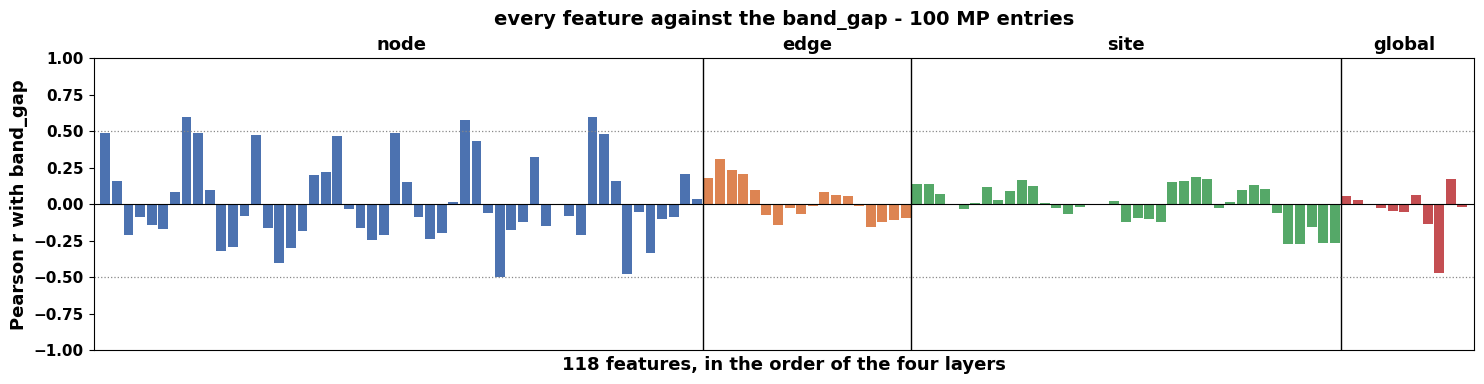

,layer,r
electron affinity bin 10/10,node,0.599
group 17,node,0.599
7 valence electrons,node,0.575
ionization energy bin 4/10,node,-0.498
period 2,node,0.490
group 1,node,0.489
1 valence electron,node,0.489
block s,node,0.479
electronegativity bin 2/10,node,0.477
block d,node,-0.475


  node    max |r| 0.599,  columns with |r| > 0.5: 3
  edge    max |r| 0.309,  columns with |r| > 0.5: 0
  site    max |r| 0.269,  columns with |r| > 0.5: 0
  global  max |r| 0.470,  columns with |r| > 0.5: 0


In [25]:
TARGET = "band_gap"     # try "density", "vpa" or "spacegroup_number" too - see below

y = mp100[TARGET].to_numpy(dtype=float)
R = FEAT.corrwith(pd.Series(y, index=FEAT.index))

COLOUR = {"node": "#4C72B0", "edge": "#DD8452", "site": "#55A868", "global": "#C44E52"}


def plot_layer_correlation(R, blocks, target):
    """One bar per feature: its correlation with the target, the four layers split by colour."""
    fig, ax = plt.subplots(figsize=(15, 4.0))
    lo = 0
    for name, block in blocks.items():
        hi = lo + block.shape[1]
        ax.bar(range(lo, hi), R.iloc[lo:hi].to_numpy(), color=COLOUR[name], width=0.85)
        if lo:
            ax.axvline(lo - 0.5, color="k", lw=1.0)
        ax.text((lo + hi - 1) / 2, 1.03, name, ha="center", va="bottom", fontsize=13)
        lo = hi
    ax.axhline(0, color="k", lw=0.8)
    for level in (-0.5, 0.5):
        ax.axhline(level, color="#888888", ls=":", lw=0.9)
    ax.set_xlim(-1, len(R)); ax.set_ylim(-1, 1); ax.set_xticks([])
    ax.set_xlabel(f"{len(R)} features, in the order of the four layers")
    ax.set_ylabel(f"Pearson r with {target}")
    ax.set_title(f"every feature against the {target} - {len(FEAT)} MP entries", pad=24,
                 fontsize=14)
    plt.tight_layout()


plot_layer_correlation(R, BLOCK, TARGET)
plt.show()

layer_of = {c: k for k, b in BLOCK.items() for c in b.columns}
top = R.abs().sort_values(ascending=False).head(10).index
display(pd.DataFrame({"layer": [layer_of[c] for c in top], "r": R[top].round(3)}))
for k, b in BLOCK.items():
    print(f"  {k:7s} max |r| {R[b.columns].abs().max():.3f},  columns with |r| > 0.5: "
          f"{int((R[b.columns].abs() > 0.5).sum())}")

The band gap sits almost entirely in the node layer. Its best columns reach |r| = 0.60 and
three of them pass 0.5, while the edge layer stops at 0.31 and the site layer at 0.27. The
strongest entry in the global layer is the density, at -0.47.

Which node columns they are is the useful part. The top of the list is the highest
electron-affinity bin and group 17 — F, Cl, Br, I — at 0.599, then a valence-electron bin, an
ionization-energy bin, and the s-block and d-block columns with opposite signs. Every one of
them is a way of saying how ionic the compound is, which is the textbook first answer to what
opens a gap. The geometry of the neighbourhood, bond lengths in the edge layer and
coordination shapes in the site layer, barely moves with the gap across these 100 crystals.

A correlation coefficient looks at one column at a time and sees only a straight line, so a
feature can be flat here and still be worth carrying in combination with others. The next
cell puts that to the test: each candidate feature set goes into a ridge regression, and the
score is the cross-validated R², repeated over three different fold splits.

In [26]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

COMBOS = {"node": ["node"], "edge": ["edge"], "site": ["site"], "global": ["global"],
          "node + edge": ["node", "edge"], "node + site": ["node", "site"],
          "node + global": ["node", "global"], "edge + site": ["edge", "site"],
          "all four": list(BLOCK)}
# a slot left empty in RECIPE drops out of the table
COMBOS = {n: k for n, k in COMBOS.items() if all(x in BLOCK for x in k)}


def ridge_r2(cols, target, seeds=(0, 1, 2)):
    """Cross-validated R^2 of a ridge fit, repeated with three different fold splits."""
    model = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-1, 6, 29), cv=5))
    r2 = [cross_val_score(model, FEAT[cols], target, scoring="r2",
                          cv=KFold(5, shuffle=True, random_state=k)).mean() for k in seeds]
    return np.mean(r2), np.min(r2), np.max(r2)


rows = []
for name, keys in COMBOS.items():
    cols = [c for k in keys for c in BLOCK[k].columns]
    mean_r2, lo_r2, hi_r2 = ridge_r2(cols, y)
    rows.append({"features": name, "dim": len(cols), "R2": round(mean_r2, 2),
                 "lowest": round(lo_r2, 2), "highest": round(hi_r2, 2)})
display(pd.DataFrame(rows).set_index("features"))

,dim,R2,lowest,highest
features,,,,
node,52,0.53,0.49,0.56
edge,18,-0.09,-0.10,-0.08
site,37,-0.12,-0.18,-0.05
global,11,0.01,-0.02,0.06
node + edge,70,0.54,0.52,0.59
node + site,89,0.48,0.41,0.53
node + global,63,0.54,0.50,0.56
edge + site,55,-0.14,-0.22,-0.05
all four,118,0.51,0.46,0.54


The table answers the question the correlations left open. For the band gap the node layer
carries the whole score, 0.53, and the sets that leave it out land at zero or below — a
model that does worse than predicting the mean gap of the training set every time. Adding the
edge layer to the node layer moves 0.53 to 0.54, which is inside the spread of the three fold
splits, so on these 100 crystals it buys nothing. Adding the site layer makes it worse, 0.48,
and throwing in all four is worse still, 0.51 from 118 columns against 100 crystals.

So a feature set designed for the band gap is the node layer, that is the element identity,
and the rest is weight. That is not a statement about the band gap in general — it is a
statement about 100 crystals, a linear model, and a representation pooled without
convolution. The geometry layers being flat here is exactly the gap that a CGCNN convolution
is built to close: it lets the neighbours change the node vector before the mean is taken, so
the same element in two different environments stops being the same number.

Two things to notice before the exercises. The `lowest` and `highest` columns are not
decoration: `all four` moves between 0.46 and 0.54 depending only on how the folds fall,
while `node` stays between 0.49 and 0.56. A single split would have let either set look like
the winner. And 118 features on 100 crystals is already more columns than materials, which is
where a fit starts to describe the sample instead of the property.

**Your turn.**

- Set `TARGET` to `"density"`, `"vpa"` or `"spacegroup_number"` and read the table again. The
  R² is 1.00, and the correlation figure shows which column gives it away: `global` holds the
  density, the volume per atom and the space-group number themselves. The target is inside
  the feature set — that is what leakage looks like, and it is the most common way a model
  comes out perfect.
- Add names from the catalogue to the `global` slot of `RECIPE` — `"DensityFeatures"`,
  `"StructuralHeterogeneity"` — rerun the two cells and see whether the band gap moves at all.
- Swap the `site` slot for `"VoronoiFingerprint"` or `"LocalPropertyDifference"`. Writing the
  geometry down differently is what decides whether that flat layer comes alive.
- Swap the `node` slot for `"atomic_number"` or `"element_raw"`. What does each of the three
  encodings of Part 3 - 92 columns, 4, 1 - score? The question is whether twenty times the
  columns shows up in the score.
- Empty the `node` slot with `[]` and rerun. How far do the other three get on their own?
- Rebuild the edge block with a different `radius` and `max_num_nbr` in `neighbour_list`, or
  a different `step` in `expand_distance`, and see whether any of it reaches the gap.
- Pick the feature set you would actually use, and write down in one line what it is that the
  chosen layers know about a crystal.

## Part 8: The features a trained band-gap model takes

The CGCNN repository ships a model trained on Materials Project for the band gap, and the
file says what that model is fed. `data/cgcnn_band_gap.pth.tar` is the file,
`pre-trained/band-gap.pth.tar` from the repository (MIT License).

The trained numbers are not needed to answer that, and we do not read them. What a layer
multiplies is what it accepts, so the *shape* of each layer fixes the width of its input. No
`torch` either: a checkpoint of this vintage begins with four pickles — a magic number, the
protocol, the system information and the object — and the shapes sit in that object. The raw
float arrays that follow are left where they are.

In [27]:
import pickle
from collections import OrderedDict

CKPT = DATA_DIR / "cgcnn_band_gap.pth.tar"
if not CKPT.is_file():
    raise FileNotFoundError(
        f"Could not find {CKPT}. Run the git clone cell in Part 1.")


def read_layer_shapes(path):
    """Read the shape of every layer of a torch checkpoint of this vintage, without torch.

    Only the shapes are wanted: what a layer multiplies is what it accepts, so its shape is
    the width of its input. A tensor arrives in the pickle as a call to _rebuild_tensor_v2,
    so the shape is caught there, and the trained numbers themselves - the raw float arrays
    written after the pickles - are never read.
    """
    def rebuild(storage, offset, size, *rest):
        return tuple(size)

    class Reader(pickle.Unpickler):
        def persistent_load(self, pid):          # ('storage', dtype, key, device, numel)
            return pid

        def find_class(self, module, name):
            if name in ("_rebuild_tensor_v2", "_rebuild_tensor"):
                return rebuild
            if name == "OrderedDict":
                return OrderedDict
            return type(name, (), {})            # storage classes and anything unused

    with open(path, "rb") as f:
        for _ in range(3):                       # magic number, protocol, system info
            Reader(f, encoding="latin1").load()
        obj = Reader(f, encoding="latin1").load()
    return obj, dict(obj["state_dict"])


ckpt, shape = read_layer_shapes(CKPT)

ATOM_FEA = shape["embedding.weight"][0]                        # the width inside the network
NODE_IN = shape["embedding.weight"][1]                         # what one node hands over
EDGE_IN = shape["convs.0.fc_full.weight"][1] - 2 * ATOM_FEA    # atom + neighbour + edge
GLOBAL_IN = shape["conv_to_fc.weight"][1] - ATOM_FEA           # added after the pooling

print(f"{CKPT.name}  ({CKPT.stat().st_size / 1024:.0f} KB), "
      f"trained on {ckpt['args']['dataset']} for {ckpt['args']['data_options'][2]}")
print(f"  embedding.weight       {str(shape['embedding.weight']):10s} "
      f"-> a node hands over {NODE_IN} numbers")
print(f"  convs.0.fc_full.weight {str(shape['convs.0.fc_full.weight']):10s} "
      f"-> reads {shape['convs.0.fc_full.weight'][1]} = 2 x {ATOM_FEA} "
      f"(atom + neighbour) + {EDGE_IN} per edge")
print(f"  conv_to_fc.weight      {str(shape['conv_to_fc.weight']):10s} "
      f"-> reads {shape['conv_to_fc.weight'][1]} = the pooled atom vector "
      f"and {GLOBAL_IN} besides")
print()

display(pd.DataFrame([
    {"slot": "node (one per atom)", "width": NODE_IN,
     "what fills it": "atom_init.json: nine element properties, one-hot",
     "in the CGCNN code": "AtomCustomJSONInitializer"},
    {"slot": "edge (one per neighbour)", "width": EDGE_IN,
     "what fills it": f"the distance, spread over {EDGE_IN} Gaussians "
                      f"{DMIN:.0f}-{DMAX:.0f} A every {STEP} A",
     "in the CGCNN code": "GaussianDistance"},
    {"slot": "edge (which neighbour)", "width": MAX_NBR,
     "what fills it": f"the index of the neighbour, {MAX_NBR} per atom within {RADIUS} A",
     "in the CGCNN code": "CIFData.__getitem__"},
    {"slot": "global (one per crystal)", "width": GLOBAL_IN,
     "what fills it": "nothing - there is no slot to fill",
     "in the CGCNN code": "-"},
]).set_index("slot"))

n = len(anatase)
print(f"so for anatase, {n} atoms, the model is handed: node ({n}, {NODE_IN}), "
      f"edge ({n}, {MAX_NBR}, {EDGE_IN}), neighbour index ({n}, {MAX_NBR}), "
      f"and no global vector")

cgcnn_band_gap.pth.tar  (773 KB), trained on matproj for band_gap
  embedding.weight       (64, 92)   -> a node hands over 92 numbers
  convs.0.fc_full.weight (128, 169) -> reads 169 = 2 x 64 (atom + neighbour) + 41 per edge
  conv_to_fc.weight      (32, 64)   -> reads 64 = the pooled atom vector and 0 besides



,width,what fills it,in the CGCNN code
slot,,,
node (one per atom),92,"atom_init.json: nine element properties, one-hot",AtomCustomJSONInitializer
edge (one per neighbour),41,"the distance, spread over 41 Gaussians 0-8 A e...",GaussianDistance
edge (which neighbour),12,"the index of the neighbour, 12 per atom within...",CIFData.__getitem__
global (one per crystal),0,nothing - there is no slot to fill,-


so for anatase, 12 atoms, the model is handed: node (12, 92), edge (12, 12, 41), neighbour index (12, 12), and no global vector


**92 on a node, 41 on an edge, nothing on the crystal.**

**A node is `atom_init.json` and nothing else.** Nine element properties, each one binned and
written as one-hot columns — group 19, period 7, electronegativity 10, covalent radius 10,
valence electrons 12, ionization energy 10, electron affinity 10, block 4, atomic volume 10,
which is the 92. A node therefore says which element sits at that site, and says nothing
about where the site is or what surrounds it.

**An edge is 41 numbers**, the distance to the neighbour spread over fixed Gaussians, plus
the index of the neighbouring atom. The graph itself is not in the checkpoint, because it is
not a trained quantity: it sits in `cgcnn/data.py` as the signature
`CIFData(root_dir, max_num_nbr=12, radius=8, dmin=0, step=0.2)`, which `main.py` does not
expose as an option, and 41 is exactly `len(np.arange(0, 8 + 0.2, 0.2))`. So the width pins
the rest down too: 0 to 8 Å in steps of 0.2 Å, at most 12 neighbours per atom.

**The global slot does not exist.** `conv_to_fc` reads 64 numbers, which is the pooled atom
vector and nothing beside it. No lattice constant, no density, no space group is handed to
the network. Crystal-level information reaches the answer only as the mean over the atoms of
node vectors that four convolutions have already mixed with their neighbours and their edges.

`predict.py` builds the network from the widths it reads off the data it is given, so a node
table that is not 92 wide, or an edge block that is not 41, will not load these weights. The
widths are not the band gap's own either: the six other regression models in the repository —
formation energy, final energy, Fermi energy, bulk and shear moduli, Poisson ratio — take
exactly the same 92, 41 and 0. One featurization serves every property.

First the two slots that are filled, drawn.

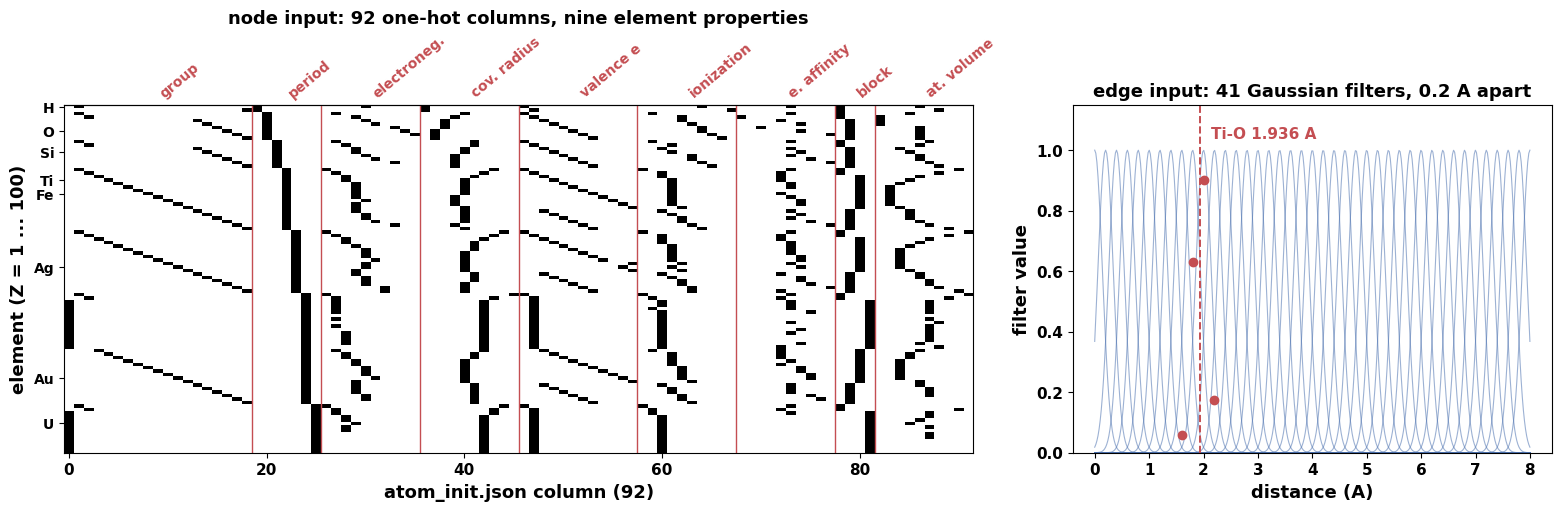

a 1.936 A bond turns into: 0.06 at 1.6 A, 0.63 at 1.8 A, 0.90 at 2.0 A, 0.17 at 2.2 A, and 0 in the other 37 filters


In [28]:
from pymatgen.core import Element

Z_LIST = sorted(map(int, raw))
symbol = [Element.from_Z(z).symbol for z in Z_LIST]
edges = np.cumsum([0] + widths)
SHORT = {"electronegativity": "electroneg.", "covalent radius": "cov. radius",
         "valence electrons": "valence e", "ionization energy": "ionization",
         "electron affinity": "e. affinity", "atomic volume": "at. volume"}
short = [SHORT.get(p, p) for p in PROPS]


def prop_axis(ax, colour="k"):
    """Name the nine property blocks along the top of an axis that spans the 92 columns."""
    top = ax.secondary_xaxis("top")
    top.set_xticks(edges[:-1] + np.array(widths) / 2 - 0.5)
    top.set_xticklabels(short, rotation=40, ha="left", fontsize=10, color=colour)
    top.tick_params(length=0)
    for e in edges[1:-1]:
        ax.axvline(e - 0.5, color=colour, lw=1.0)


def panel_node_table(ax):
    """Left panel - the whole of atom_init.json: one row per element, 92 columns."""
    ax.imshow(table, cmap="Greys", aspect="auto", interpolation="nearest")
    prop_axis(ax, "#C44E52")
    yt = [i for i, z in enumerate(Z_LIST) if z in (1, 8, 14, 22, 26, 47, 79, 92)]
    ax.set_yticks(yt); ax.set_yticklabels([symbol[i] for i in yt], fontsize=10)
    ax.set_xlabel("atom_init.json column (92)")
    ax.set_ylabel("element (Z = 1 ... 100)")
    ax.set_title("node input: 92 one-hot columns, nine element properties", fontsize=13)


def panel_gaussian_filters(ax, bond, resp):
    """Right panel - the 41 Gaussian filters, and which of them one bond switches on."""
    grid = np.linspace(DMIN, DMAX, 400)
    for c in centres:
        ax.plot(grid, np.exp(-(grid - c) ** 2 / STEP ** 2), lw=0.8, color="#4C72B0",
                alpha=0.55)
    ax.axvline(bond, color="#C44E52", lw=1.4, ls="--")
    ax.plot(centres[resp > 0.01], resp[resp > 0.01], "o", color="#C44E52", ms=6)
    ax.text(bond + 0.2, 1.04, f"Ti-O {bond:.3f} A", color="#C44E52", fontsize=11)
    ax.set_xlabel("distance (A)"); ax.set_ylabel("filter value"); ax.set_ylim(0, 1.15)
    ax.set_title(f"edge input: {len(centres)} Gaussian filters, {STEP} A apart", fontsize=13)


BOND = nbr_dist[0].min()                       # the anatase Ti-O bond found in Part 2
resp = expand_distance(np.array([BOND]))[0]

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.0), width_ratios=[1.9, 1],
                         layout="constrained")
panel_node_table(axes[0])
panel_gaussian_filters(axes[1], BOND, resp)
plt.show()

print(f"a {BOND:.3f} A bond turns into: " +
      ", ".join(f"{v:.2f} at {c:.1f} A" for c, v in zip(centres, resp) if v > 0.01) +
      f", and 0 in the other {(resp <= 0.01).sum()} filters")

On the left is the whole of `atom_init.json`: one row per element, 92 columns, black where
the bin is on. The red lines separate the nine properties, and a row carries one black square
inside each block — except where a property has no value for that element, which is why the
rows hold between 6 and 9 of them. There is nothing else in a node. Not the site, not the
neighbours: only which element sits there.

On the right is the edge input. The 41 filters are fixed Gaussians 0.2 Å apart, so a distance
does not enter as a number but as the responses it draws. The shortest bond in anatase,
Ti–O at 1.936 Å, lights up four of them — 0.90 at the 2.0 Å centre, 0.63 at 1.8, 0.17 at 2.2
and 0.06 at 1.6 — and leaves the other 37 at zero. That, and the index of the neighbour, is
everything the network is told about a bond.

Now the three slots side by side, and what these features tell the network.

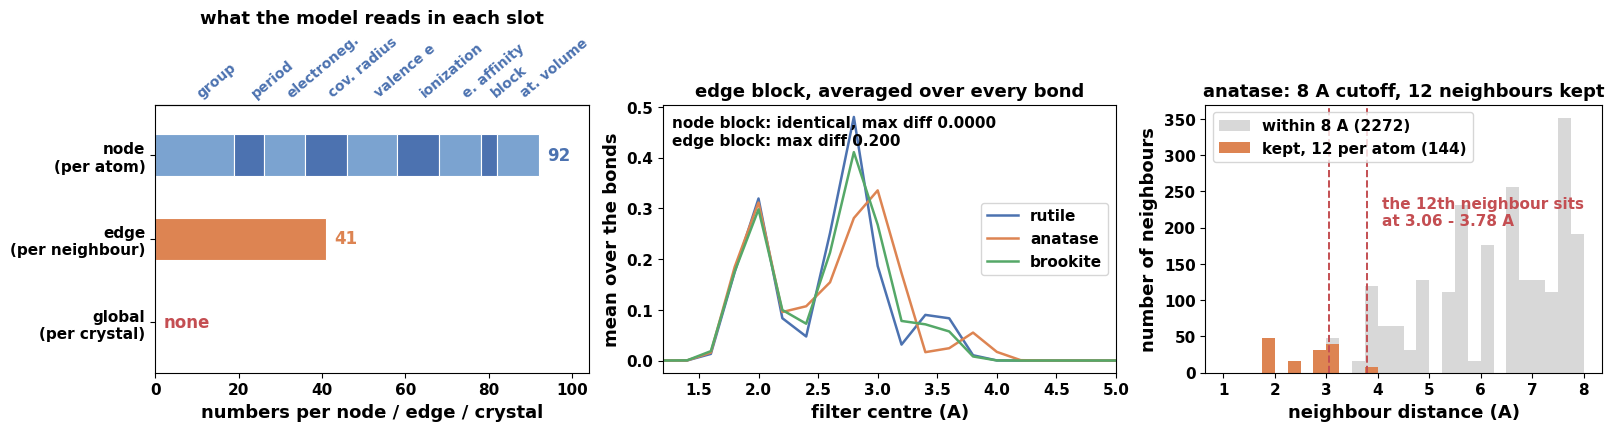

node input, 92 one-hot columns: group 19, period 7, electronegativity 10, covalent radius 10, valence electrons 12, ionization energy 10, electron affinity 10, block 4, atomic volume 10
pooled over the atoms, the node block gives the three TiO2 polymorphs the same vector (max difference 0.0000)
the edge block differs by up to 0.200: rutile peaks at 2.8 A, anatase peaks at 3.0 A, brookite peaks at 2.8 A
anatase has 188-190 neighbours per atom inside 8 A; 12 of them enter the graph, so the effective cutoff is 3.06-3.78 A


In [29]:
pooled_poly = {}
for f in POLY:
    s = Structure.from_file(CIF_DIR / f)
    pooled_poly[f.removeprefix("TiO2_").removesuffix(".cif")] = (
        node_features(s, raw).mean(axis=0),                        # node block, pooled
        expand_distance(neighbour_list(s)[1]).mean(axis=(0, 1)))   # edge block, pooled


def max_gap(block):
    """Largest difference between two polymorphs; block 0 is node, 1 is edge."""
    return max(np.abs(pooled_poly[a][block] - pooled_poly[b][block]).max()
               for a in pooled_poly for b in pooled_poly)


d_node, d_edge = max_gap(0), max_gap(1)


def panel_slot_widths(ax):
    """Left panel - how many numbers the model reads in each of its three slots.
    The node bar is split into the nine element properties that make up the 92 one-hot columns."""
    lo = 0
    for k, w in enumerate(widths):
        ax.barh(0, w, left=lo, height=0.5, color=("#4C72B0" if k % 2 else "#7BA3D0"),
                edgecolor="white", lw=0.8)
        lo += w
    ax.barh(1, EDGE_IN, height=0.5, color="#DD8452", edgecolor="white", lw=0.8)
    ax.text(NODE_IN + 2, 0, f"{NODE_IN}", va="center", fontsize=12, color="#4C72B0")
    ax.text(EDGE_IN + 2, 1, f"{EDGE_IN}", va="center", fontsize=12, color="#DD8452")
    ax.text(2, 2, "none", va="center", fontsize=12, color="#C44E52")
    top = ax.secondary_xaxis("top")
    top.set_xticks(np.cumsum([0] + widths)[:-1] + np.array(widths) / 2)
    top.set_xticklabels(short, rotation=40, ha="left", fontsize=10, color="#4C72B0")
    top.tick_params(length=0)
    ax.set_yticks(range(3))
    ax.set_yticklabels(["node\n(per atom)", "edge\n(per neighbour)",
                        "global\n(per crystal)"], fontsize=11)
    ax.set_ylim(2.6, -0.6); ax.set_xlim(0, 104)
    ax.set_xlabel("numbers per node / edge / crystal")
    ax.set_title("what the model reads in each slot", fontsize=13)


def panel_edge_blocks(ax):
    """Middle panel - the edge block averaged over every bond.
    The node block is fixed by the element alone and is identical across the three
    polymorphs, so this is the only place they part."""
    COL = {"rutile": "#4C72B0", "anatase": "#DD8452", "brookite": "#55A868"}
    for name, (_, e) in pooled_poly.items():
        ax.plot(centres, e, lw=1.8, color=COL[name], label=name)
    ax.text(0.02, 0.96, f"node block: identical, max diff {d_node:.4f}\n"
                        f"edge block: max diff {d_edge:.3f}",
            transform=ax.transAxes, va="top", fontsize=11)
    ax.set_xlim(1.2, 5.0)
    ax.set_xlabel("filter centre (A)")
    ax.set_ylabel("mean over the bonds")
    ax.set_title("edge block, averaged over every bond", fontsize=13)
    ax.legend(fontsize=11)


def panel_reach(ax):
    """Right panel - how much of the crystal the graph sees at all.
    The 12-neighbour cap decides this, not the 8 A cutoff."""
    d_all = np.concatenate([[nbr[1] for nbr in row]
                            for row in anatase.get_all_neighbors(RADIUS, include_index=True)])
    bins = np.arange(1.0, RADIUS + 0.25, 0.25)
    ax.hist(d_all, bins=bins, color="#D8D8D8", label=f"within {RADIUS} A ({d_all.size})")
    ax.hist(nbr_dist.ravel(), bins=bins, color="#DD8452",
            label=f"kept, {MAX_NBR} per atom ({nbr_dist.size})")
    for x in (nbr_dist[:, -1].min(), nbr_dist[:, -1].max()):
        ax.axvline(x, color="#C44E52", ls="--", lw=1.4)
    ax.text(nbr_dist[:, -1].max() + 0.3, ax.get_ylim()[1] * 0.55,
            f"the 12th neighbour sits\nat {nbr_dist[:, -1].min():.2f} - "
            f"{nbr_dist[:, -1].max():.2f} A", color="#C44E52", fontsize=11)
    ax.set_xlabel("neighbour distance (A)")
    ax.set_ylabel("number of neighbours")
    ax.set_title(f"anatase: {RADIUS} A cutoff, {MAX_NBR} neighbours kept", fontsize=13)
    ax.legend(fontsize=11, loc="upper left")


fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), width_ratios=[1.15, 1.2, 1.05],
                         layout="constrained")
panel_slot_widths(axes[0])
panel_edge_blocks(axes[1])
panel_reach(axes[2])
plt.show()

print("node input, 92 one-hot columns: "
      + ", ".join(f"{p} {w}" for p, w in zip(PROPS, widths)))
print(f"pooled over the atoms, the node block gives the three TiO2 polymorphs the same "
      f"vector (max difference {d_node:.4f})")
print(f"the edge block differs by up to {d_edge:.3f}: "
      + ", ".join(f"{n} peaks at {centres[e.argmax()]:.1f} A"
                  for n, (_, e) in pooled_poly.items()))
print(f"anatase has {min(len(r) for r in anatase.get_all_neighbors(RADIUS)):d}-"
      f"{max(len(r) for r in anatase.get_all_neighbors(RADIUS)):d} neighbours per atom "
      f"inside {RADIUS} A; {MAX_NBR} of them enter the graph, so the effective cutoff is "
      f"{nbr_dist[:, -1].min():.2f}-{nbr_dist[:, -1].max():.2f} A")

Three things about these features.

**A node carries no geometry.** Pooled over the atoms, the node block gives the three TiO₂
polymorphs exactly the same vector (middle panel, largest difference 0.0000). Same
composition, same elements, so the same 92 columns — nothing in that slot separates rutile
from anatase.

**The structure is in the edge block.** The same three crystals differ there by up to 0.200:
rutile and brookite put their strongest band at 2.8 Å, anatase puts its own at 3.0 Å. The
distances are where the identity of a crystal sits, and the convolution is what carries them
into the nodes before the mean is taken.

**The graph is narrower than the 8 Å cutoff suggests.** Anatase has 188 to 190 neighbours per
atom inside 8 Å and only 12 of them are kept, so the real reach is the 12th neighbour, at
3.06 to 3.78 Å. What the model is shown of a crystal is a couple of shells around each atom
— which is also why the empty global slot is not a hole in the input: every crystal-level
quantity has to be rebuilt from those shells and from the mean over the atoms.

## References and citations

- **CGCNN** — <https://github.com/txie-93/cgcnn> (T. Xie, MIT License). The way the
  neighbours are chosen and the `GaussianDistance` expansion are written out from
  `CIFData.__getitem__` in `cgcnn/data.py`, and
  the element feature table `atom_init.json` is the repository file itself
  (`data/cgcnn_atom_init.json`; the full licence is in `data/cgcnn_LICENSE.txt`). The
  band-gap model read in Part 8 is `pre-trained/band-gap.pth.tar` from the same
  repository (`data/cgcnn_band_gap.pth.tar`), trained on Materials Project data by the
  author; only the shapes of its layers are read there. The target property of every
  pre-trained model is listed in `pre-trained/README.md`.
- **CGCNN_tutorial** — <https://github.com/Diego-2504/CGCNN_tutorial>.
  A notebook walkthrough of the CGCNN code. The "one atomic number per node" encoding
  compared in Part 3 is in its `Crystal_graphs` notebook.
- **GNN-materials** — <https://github.com/polbeni/GNN-materials>
  (P. Benítez Colominas, MIT License). The other set of choices compared in Part 2 and
  Part 3 — four element properties written as they are
  (`create-graphs/atoms_dict.json`), every neighbour inside the cutoff with no count limit,
  and periodicity handled by building a supercell (`create-graphs/`). A variant that writes
  the directional components of a bond onto the edge as well sits in `edge-multifeature/`.
- **matminer** — <https://hackingmaterials.lbl.gov/matminer/>, the site and structure
  featurizer lists.
- **matminer-notes** (`codes/matminer-notes.ipynb`) — the shape and the voice of this
  notebook.
- **Materials Project** (CC BY 4.0) — every crystal structure in `data/cif/`, the 100
  entries of `data/mp100_*` used in Part 7, and the training data behind the
  pre-trained CGCNN models (A. Jain *et al.*, *APL Mater.* **1**, 011002 (2013)).

Original papers

- T. Xie & J. C. Grossman, *Phys. Rev. Lett.* **120**, 145301 (2018) — CGCNN
- L. Ward *et al.*, *Comput. Mater. Sci.* **152**, 60 (2018) — matminer
- S. P. Ong *et al.*, *Comput. Mater. Sci.* **68**, 314 (2013) — pymatgen
- P. Benítez *et al.*, arXiv:2511.15222 (2025) — GNN-materials

Sources of the site featurizers attached in Part 3, as reported by `citations()`.

- A. Seko *et al.*, *Phys. Rev. B* **95**, 144110 (2017) — `SiteElementalProperty`
- N. E. R. Zimmermann & A. Jain, *RSC Adv.* **10**, 6063 (2020) — the
  coordination-geometry order parameters behind `CrystalNNFingerprint`
- A. Okabe *et al.*, *Spatial Tessellations* (1992) — the Voronoi tessellation behind
  `CoordinationNumber` and `VoronoiFingerprint`
- H. L. Peng, M. Z. Li & W. H. Wang, *Phys. Rev. Lett.* **106**, 135503 (2011) —
  `VoronoiFingerprint`
- Q. Wang & A. Jain, *Nat. Commun.* **10**, 5537 (2019) — `VoronoiFingerprint`
- J. Behler, *J. Chem. Phys.* **134**, 074106 (2011) — `GaussianSymmFunc`
- A. Khorshidi & A. A. Peterson, *Comput. Phys. Commun.* **207**, 310 (2016) — the
  `GaussianSymmFunc` implementation
- V. Botu & R. Ramprasad, *Int. J. Quantum Chem.* **115**, 1074 (2015) — `AGNIFingerprints`
- M. de Jong *et al.*, *Sci. Rep.* **6**, 34256 (2016) — `AverageBondLength` and
  `AverageBondAngle`
- L. Ward *et al.*, *Phys. Rev. B* **96**, 024104 (2017) — `LocalPropertyDifference`, and
  `MaximumPackingEfficiency`, `ChemicalOrdering`, `StructuralHeterogeneity` in Part 5
- S. V. Krivovichev, *Mineral. Mag.* **77**, 275 (2013) — `StructuralComplexity`
- P. M. Larsen *et al.*, *Phys. Rev. Mater.* **3**, 034003 (2019) — `Dimensionality`